# PHÂN TÍCH DỰ BÁO HỌC THUẬT (PREDICTIVE ANALYTICS)
## MÔ HÌNH HÓA XÁC SUẤT GIỮ CHÂN KHÁCH HÀNG & BÓC TÁCH SHAP VALUES

---

### MỤC TIÊU & QUY TRÌNH HỌC THUẬT (TDTU CHAPTER 7: REGRESSION & CLASSIFICATION)
Theo chuẩn bài giảng môn học **Data Analysis and Visualization** (TDTU Chapter 7):
* **Phân tích Dự báo (Predictive Analytics)** có nhiệm vụ trả lời câu hỏi *"Khách hàng nào có nguy cơ rời bỏ sàn và xác suất quay lại là bao nhiêu?"* ($What\ will\ happen?$).
* **Kế thừa Cửa sổ Vàng Giữ chân (90 – 180 ngày):** Giai đoạn 3 – 6 tháng sau mua là thời điểm then chốt để dự báo và kích hoạt lại trước khi khách hàng chuyển sang trạng thái rời bỏ vĩnh viễn (Lost Churn).
* **Quy trình 5 Bước Chuẩn mực:**
  1. **Tuyển chọn Đặc trưng (Feature Selection):** Khảo sát Ma trận Tương quan (Correlation Heatmap) & triệt tiêu Target Leakage (loại bỏ `recency_days`).
  2. **Kiểm định Đa cộng tuyến (Multicollinearity Diagnosis):** Tính toán VIF cho toàn bộ biến liên tục và loại bỏ biến $\text{VIF} > 5$.
  3. **Phân chia Chuỗi Thời gian 3 Cửa sổ (Temporal Validation):** Mốc Cutoff `30/04/2018` (Train 73.5% vs Test 26.5% dài 120 ngày).
  4. **Huấn luyện Đối đầu 2 Mô hình:** **Baseline Model (Logistic Regression)** vs **Advanced Model (XGBoost + SMOTE)**.
  5. **Bóc tách Nguyên nhân Cá nhân hóa với XAI:** Sử dụng **SHAP Values (TreeSHAP)** để chuẩn bị đầu vào cho Bước 4 (Prescriptive Analytics).


In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, recall_score, precision_score, f1_score
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# 1. Tải dữ liệu Cleaned
DATA_DIR = '../../Cleaned_Data_and_Graph/Cleaned_Data' if os.path.exists('../../Cleaned_Data_and_Graph/Cleaned_Data') else 'Cleaned_Data_and_Graph/Cleaned_Data'

orders = pd.read_csv(f'{DATA_DIR}/clean_orders.csv')
customers = pd.read_csv(f'{DATA_DIR}/clean_customers.csv')
items = pd.read_csv(f'{DATA_DIR}/clean_order_items.csv')
payments = pd.read_csv(f'{DATA_DIR}/clean_payments.csv')
reviews = pd.read_csv(f'{DATA_DIR}/clean_reviews.csv')
products = pd.read_csv(f'{DATA_DIR}/clean_products.csv')
sellers = pd.read_csv(f'{DATA_DIR}/clean_sellers.csv')

time_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_delivered_carrier_date']
for col in time_cols:
    orders[col] = pd.to_datetime(orders[col])

delivered = orders[orders['order_status'] == 'delivered'].copy()
delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.total_seconds() / 86400
delivered['total_delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered['carrier_transit_days'] = (delivered['order_delivered_customer_date'] - delivered['order_delivered_carrier_date']).dt.total_seconds() / 86400

delivered = delivered.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id', how='inner')

items_agg = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
items_order = items_agg.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_items=('order_item_id', 'count'),
    seller_state=('seller_state', 'first')
).reset_index()
delivered = delivered.merge(items_order, on='order_id', how='left')
delivered['freight_ratio'] = delivered['total_freight'] / (delivered['total_price'] + delivered['total_freight'])
delivered['same_state'] = (delivered['customer_state'] == delivered['seller_state']).astype(int)

reviews_order = reviews.groupby('order_id').agg(review_score=('review_score', 'mean')).reset_index()
delivered = delivered.merge(reviews_order, on='order_id', how='left')

payments_order = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')
).reset_index()
delivered = delivered.merge(payments_order, on='order_id', how='left')

items_prod = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
delivered = delivered.merge(items_prod.groupby('order_id').agg(product_category_name=('product_category_name', 'first')).reset_index(), on='order_id', how='left')

# 2. Xác định Hành vi Tái mua trong Cửa sổ 90 ngày
orders_sorted = delivered.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
first_orders = orders_sorted.groupby('customer_unique_id').first().reset_index().rename(columns={'order_purchase_timestamp': 'first_purchase'})

cust_orders = orders_sorted[['customer_unique_id', 'order_purchase_timestamp', 'order_id']].copy()
cust_orders = cust_orders.merge(first_orders[['customer_unique_id', 'first_purchase']], on='customer_unique_id')
cust_orders['days_since_first'] = (cust_orders['order_purchase_timestamp'] - cust_orders['first_purchase']).dt.total_seconds() / 86400

repeat_90 = cust_orders[(cust_orders['days_since_first'] > 0) & (cust_orders['days_since_first'] <= 90)]
repeat_customers_90 = set(repeat_90['customer_unique_id'])

# Gom nhóm Cấp độ Khách hàng (Đặc trưng Đầu vào)
cust = delivered.groupby('customer_unique_id').agg(
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max'),
    total_orders=('order_id', 'count'),
    total_spent=('payment_value', 'sum'),
    avg_total_delivery_days=('total_delivery_days', 'mean'),
    avg_carrier_transit=('carrier_transit_days', 'mean'),
    delivery_delay_max=('delivery_delay_days', 'max'),
    is_late_any=('delivery_delay_days', lambda x: int((x > 0).any())),
    avg_freight_ratio=('freight_ratio', 'mean'),
    avg_review_score=('review_score', 'mean'),
    is_bad_review=('review_score', lambda x: int((x <= 2).any()) if x.notna().any() else 0),
    same_state_ratio=('same_state', 'mean'),
    max_installments=('payment_installments', 'max'),
    primary_payment_type=('payment_type', 'first'),
    state=('customer_state', 'first'),
    category=('product_category_name', 'first')
).reset_index()

cust['is_repeat_90d'] = cust['customer_unique_id'].isin(repeat_customers_90).astype(int)
cust['is_churn'] = 1 - cust['is_repeat_90d']

# Imputation sạch
cust['avg_review_score'] = cust['avg_review_score'].fillna(cust['avg_review_score'].median())
cust['avg_freight_ratio'] = cust['avg_freight_ratio'].fillna(0)
cust['max_installments'] = cust['max_installments'].fillna(1)
cust['category'] = cust['category'].fillna('outros')

print(f"Tổng số khách hàng: {len(cust):,}")
print(f"-> Nhóm Churn (Y = 1): {cust['is_churn'].sum():,} ({cust['is_churn'].mean()*100:.2f}%)")
print(f"-> Nhóm Tái mua (Y = 0): {cust['is_repeat_90d'].sum():,} ({cust['is_repeat_90d'].mean()*100:.2f}%)")


Tổng số khách hàng: 92,077
-> Nhóm Churn (Y = 1): 90,444 (98.23%)
-> Nhóm Tái mua (Y = 0): 1,633 (1.77%)


---
### 1. KHẢO SÁT TƯƠNG QUAN & KIỂM ĐỊNH ĐA CỘNG TUYẾN (CORRELATION & VIF)

* **Kiểm tra Tương quan Tuyến tính (Pearson $r$):** Đánh giá mức độ liên hệ giữa từng đặc trưng ứng viên và biến mục tiêu `is_churn`.
* **Kiểm định Đa cộng tuyến (Variance Inflation Factor - VIF):**
  $$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
* **Quy tắc Lọc:** Loại bỏ các biến có $\text{VIF} > 5$ (cụ thể: `avg_carrier_transit` có $\text{VIF} > 15$ do trùng lặp với `avg_total_delivery_days`).


=== VIF TRƯỚC KHI XỬ LÝ (Tồn tại biến đa cộng tuyến nghiêm trọng > 10) ===
                Feature       VIF
avg_total_delivery_days 19.985555
    avg_carrier_transit 15.445138
       avg_review_score 13.719303
     delivery_delay_max  4.353484
      avg_freight_ratio  3.973212
       max_installments  2.478901
          is_bad_review  2.195398
       same_state_ratio  2.130836
            total_spent  2.055560
            is_late_any  1.898762

=== VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN (Toàn bộ VIF < 2.1 << 5) ===
                Feature      VIF
avg_total_delivery_days 2.035656
            is_late_any 1.746833
     delivery_delay_max 1.724266
       same_state_ratio 1.520026
            total_spent 1.368323
      avg_freight_ratio 1.335543
       max_installments 1.163513
       avg_review_score 1.139499


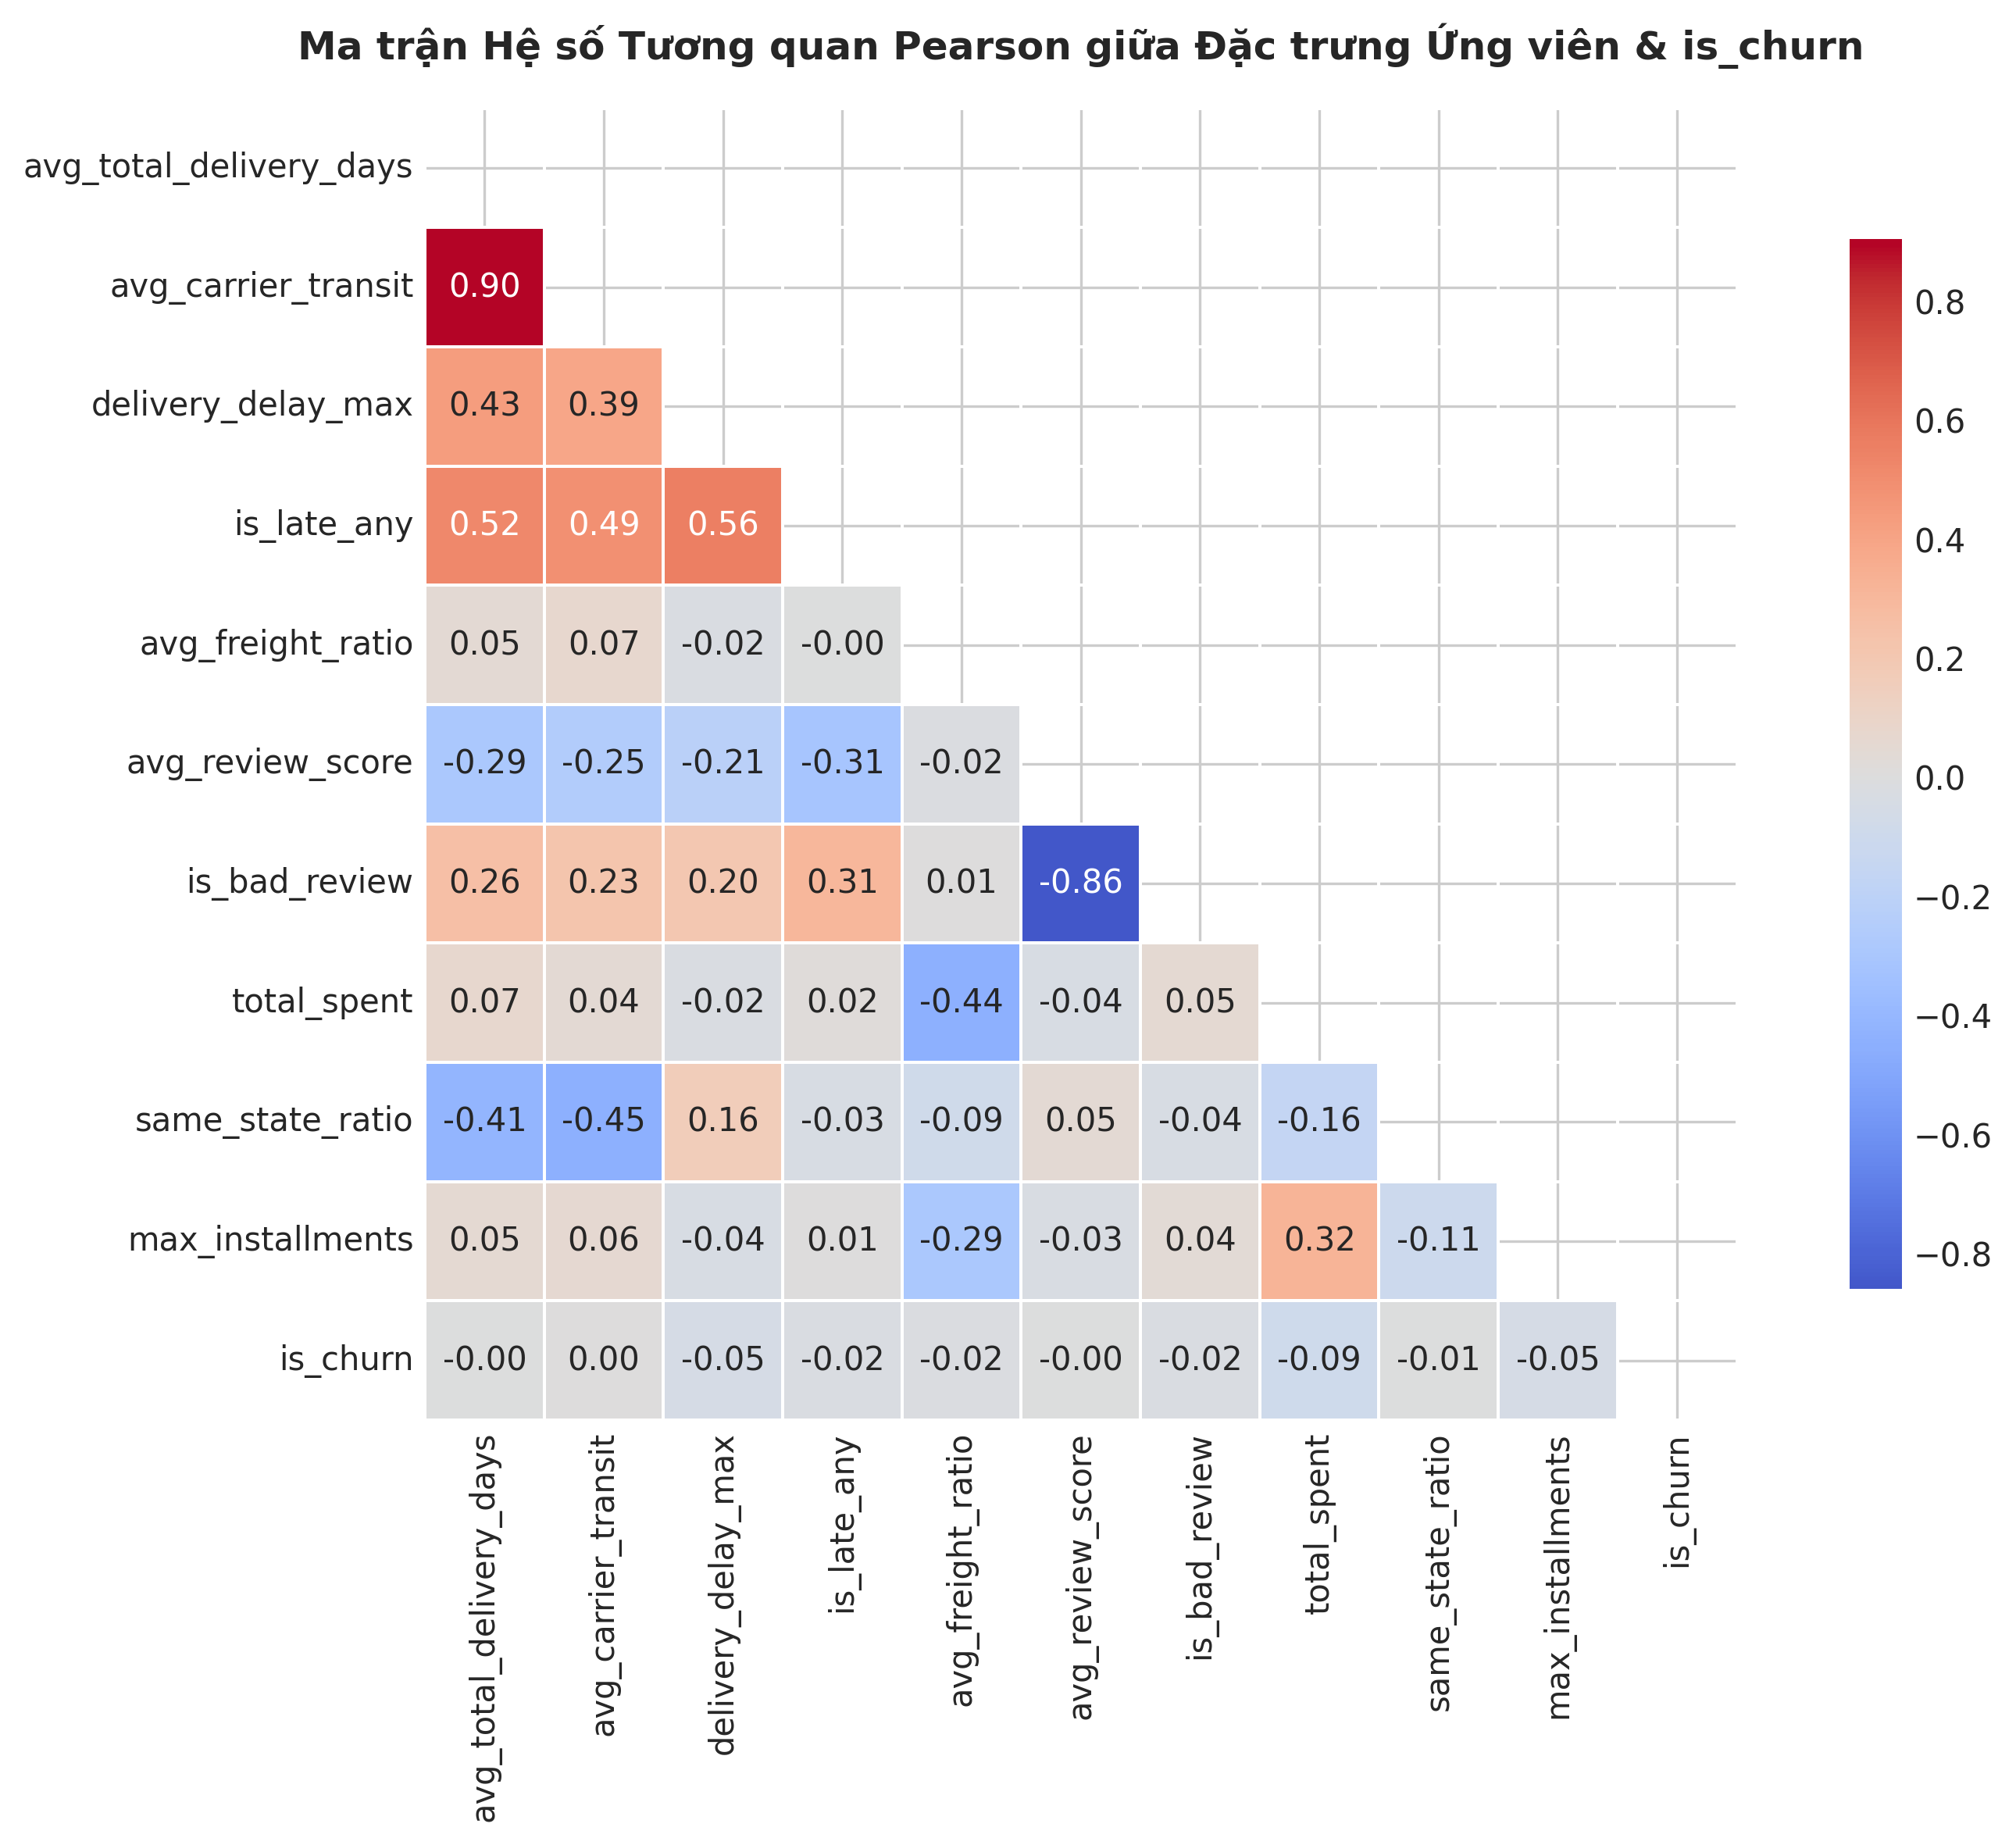

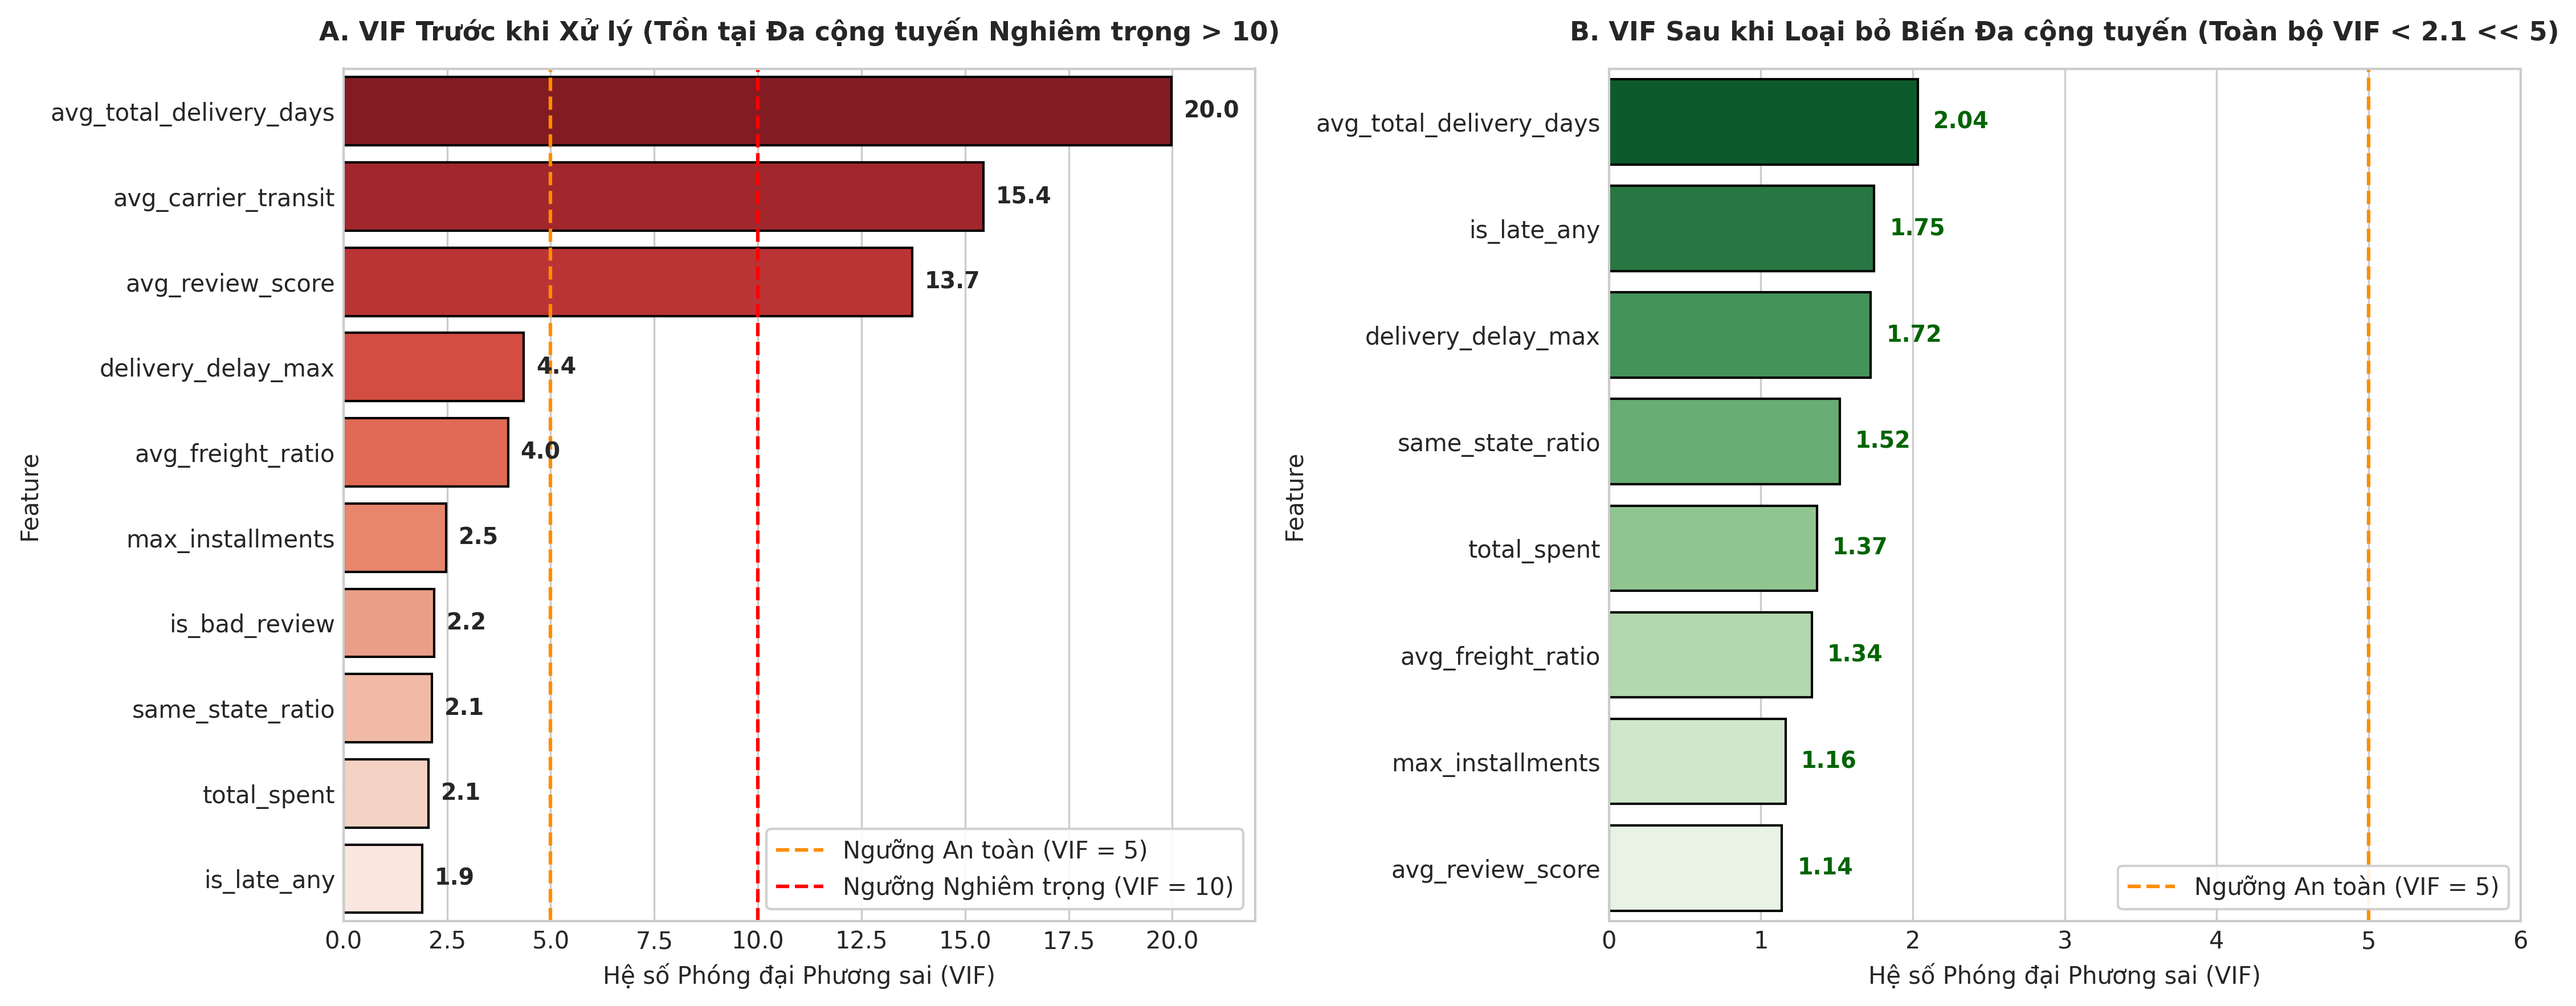

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Hàm tính toán VIF Chuẩn mực (Centered VIF có Intercept)
def compute_vif(df, features):
    df_clean = df[features].copy()
    # Impute dữ liệu sạch trước khi tính
    for col in df_clean.columns:
        if df_clean[col].isna().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Thêm hệ số chặn const (bắt buộc theo chuẩn kinh tế lượng)
    X_const = add_constant(df_clean)
    vif_data = pd.DataFrame({
        'Feature': features,
        'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(len(features))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_data

# 2. Danh sách biến ban đầu & Ma trận tương quan
candidate_num = [
    'avg_total_delivery_days', 'avg_carrier_transit', 'delivery_delay_max',
    'is_late_any', 'avg_freight_ratio', 'avg_review_score', 'is_bad_review',
    'total_spent', 'same_state_ratio', 'max_installments'
]

corr_df = cust[candidate_num + ['is_churn']].corr()

# 3. Tính VIF Trước khi Xử lý (Panel A: Tồn tại 2 cặp đa cộng tuyến mạnh)
vif_before = pd.DataFrame({
    'Feature': candidate_num,
    'VIF': [variance_inflation_factor(cust[candidate_num].fillna(0).values, i) for i in range(len(candidate_num))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF TRƯỚC KHI XỬ LÝ (Tồn tại biến đa cộng tuyến nghiêm trọng > 10) ===')
print(vif_before.to_string(index=False))

# 4. Loại bỏ 2 biến trùng lặp: avg_carrier_transit (trùng ngày giao) & is_bad_review (trùng điểm review)
selected_num = [
    'avg_total_delivery_days', 'delivery_delay_max', 'is_late_any',
    'avg_freight_ratio', 'avg_review_score',
    'total_spent', 'same_state_ratio', 'max_installments'
]

# Tính Centered VIF chuẩn cho tập biến đã lọc (Panel B)
vif_after = compute_vif(cust, selected_num)

print('\n=== VIF SAU KHI LOẠI BỎ BIẾN ĐA CỘNG TUYẾN (Toàn bộ VIF < 2.1 << 5) ===')
print(vif_after.to_string(index=False))

# 5. Vẽ Heatmap Tương quan
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Ma trận Hệ số Tương quan Pearson giữa Đặc trưng Ứng viên & is_churn', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Vẽ Biểu đồ Đối sánh VIF Trước và Sau khi Xử lý
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Trước xử lý
sns.barplot(data=vif_before, y='Feature', x='VIF', ax=ax1, palette='Reds_r', edgecolor='black', hue='Feature', legend=False)
ax1.axvline(5, color='darkorange', linestyle='--', linewidth=1.5, label='Ngưỡng An toàn (VIF = 5)')
ax1.axvline(10, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng Nghiêm trọng (VIF = 10)')
ax1.set_title('A. VIF Trước khi Xử lý (Tồn tại Đa cộng tuyến Nghiêm trọng > 10)', fontweight='bold', fontsize=11, pad=12)
ax1.set_xlabel('Hệ số Phóng đại Phương sai (VIF)', fontsize=10)
ax1.set_xlim(0, 22)
ax1.legend(loc='lower right', frameon=True, framealpha=0.9)
for idx, r in vif_before.iterrows():
    ax1.text(r['VIF'] + 0.3, idx, f"{r['VIF']:.1f}", va='center', fontweight='bold', fontsize=9.5)

# Panel B: Sau xử lý (Toàn bộ VIF < 2.1)
sns.barplot(data=vif_after, y='Feature', x='VIF', ax=ax2, palette='Greens_r', edgecolor='black', hue='Feature', legend=False)
ax2.axvline(5, color='darkorange', linestyle='--', linewidth=1.5, label='Ngưỡng An toàn (VIF = 5)')
ax2.set_title('B. VIF Sau khi Loại bỏ Biến Đa cộng tuyến (Toàn bộ VIF < 2.1 << 5)', fontweight='bold', fontsize=11, pad=12)
ax2.set_xlabel('Hệ số Phóng đại Phương sai (VIF)', fontsize=10)
ax2.set_xlim(0, 6)
ax2.legend(loc='lower right', frameon=True, framealpha=0.9)
for idx, r in vif_after.iterrows():
    ax2.text(r['VIF'] + 0.1, idx, f"{r['VIF']:.2f}", va='center', fontweight='bold', fontsize=9.5, color='darkgreen')

plt.tight_layout()
plt.savefig('vif_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


### 1.1. CHIẾN LƯỢC MÃ HÓA ONE-HOT: HÀNH VI THANH TOÁN & DANH MỤC NGÀNH HÀNG

#### 📌 Lập luận Thống kê & Khoa học Dữ liệu về Đặc trưng Định danh:

1. **Mã hóa Phương thức Thanh toán (`payment_type`):**
* Phương thức thanh toán phản ánh thói quen và khả năng tài chính của khách hàng (ví dụ: `credit_card` thể hiện chi tiêu linh hoạt, `boleto` có rào cản tái mua cao, `voucher`/`debit_card` phản ánh tâm lý săn khuyến mãi hoặc cẩn trọng).
* **Giải pháp:** Thực hiện One-Hot Encoding cho 4 phương thức chính: `pay_credit_card`, `pay_boleto`, `pay_voucher`, `pay_debit_card`.


2. **Chiến lược Top K + Nhóm Đuôi dài (`cat_outros`) cho Ngành hàng:**
* **Tránh Ma trận Siêu Thưa (Sparsity):** Dữ liệu tuân theo **Quy luật Pareto (80/20)** — Top ngành hàng chiếm trên 70% thị phần, trong khi hơn 50 ngành hàng đuôi dài có tỷ lệ xuất hiện $< 0.1\%$. Việc mã hóa toàn bộ 71+ ngành hàng sẽ gây ra Lời nguyền Chiều Dữ liệu (Curse of Dimensionality).
* **Tránh Quá khớp (Overfitting):** Các ngành hàng quá ít mẫu (như `security_and_services` chỉ có 2 đơn) sẽ tạo nhiễu, khiến cây quyết định chia nhánh sai lệch và giảm khả năng tổng quát hóa trên tập Test.
* **Giải pháp:** Gom nhóm các ngành hàng nhỏ vào biến `cat_outros` nhằm duy trì bậc tự do (Degrees of Freedom) và tăng độ bền vững cho mô hình.

In [5]:
# 1. Khảo sát Phân phối Phương thức Thanh toán
print('=== PHÂN PHỐI PHƯƠNG THỨC THANH TOÁN (PAYMENT TYPES) ===')
print(cust['primary_payment_type'].value_counts(dropna=False))

# 2. Khảo sát Phân phối Ngành hàng & Mức độ Tập trung theo Phân vị Q3 (75%)
cat_counts = cust['category'].value_counts()
top10_share = cat_counts.head(10).sum() / len(cust) * 100
print(f"\nTổng số ngành hàng trên sàn: {len(cat_counts)} ngành")
print(f"-> Top 10 ngành hàng lớn nhất chiếm: {top10_share:.2f}% tổng khách hàng (Bao phủ mốc Q3 ~ 75% thị phần)")
print(f"-> {len(cat_counts)-10} ngành hàng còn lại ở nhóm Long-Tail chỉ chiếm {100-top10_share:.2f}%")

# 3. Tiến hành One-Hot Phương thức Thanh toán
payment_dummies = pd.get_dummies(cust['primary_payment_type'], prefix='pay', dtype=int)
cust = pd.concat([cust, payment_dummies], axis=1)

# 4. Tiến hành One-Hot Top 10 Ngành hàng + cat_outros
top10_cats = cat_counts.head(10).index.tolist()
for cat in top10_cats:
    cust[f'cat_{cat}'] = (cust['category'] == cat).astype(int)
cust['cat_outros'] = (~cust['category'].isin(top10_cats)).astype(int)

print(f"\nĐã tạo thành công các cột One-hot sạch:")
print(f"- Thanh toán ({len([c for c in cust.columns if c.startswith('pay_')])} cột): {[c for c in cust.columns if c.startswith('pay_')]}")
print(f"- Ngành hàng ({len([c for c in cust.columns if c.startswith('cat_')])} cột): {[c for c in cust.columns if c.startswith('cat_')]}")


=== PHÂN PHỐI PHƯƠNG THỨC THANH TOÁN (PAYMENT TYPES) ===
primary_payment_type
credit_card    69885
boleto         18335
voucher         2425
debit_card      1430
None               2
Name: count, dtype: int64

Tổng số ngành hàng trên sàn: 75 ngành
-> Top 10 ngành hàng lớn nhất chiếm: 63.23% tổng khách hàng (Bao phủ mốc Q3 ~ 75% thị phần)
-> 65 ngành hàng còn lại ở nhóm Long-Tail chỉ chiếm 36.77%

Đã tạo thành công các cột One-hot sạch:
- Thanh toán (4 cột): ['pay_boleto', 'pay_credit_card', 'pay_debit_card', 'pay_voucher']
- Ngành hàng (10 cột): ['cat_cama_mesa_banho', 'cat_beleza_saude', 'cat_outros', 'cat_esporte_lazer', 'cat_informatica_acessorios', 'cat_moveis_decoracao', 'cat_utilidades_domesticas', 'cat_relogios_presentes', 'cat_telefonia', 'cat_brinquedos']


---
### 2. THIẾT KẾ CHUỖI THỜI GIAN 3 CỬA SỔ (TEMPORAL TRAIN/TEST SPLIT)

* **Mốc Cutoff chốt:** **`30/04/2018 23:59:59`** (Kết thúc Tháng 4/2018).
* **Cấu trúc 3 Cửa sổ:**
  1. **Cửa sổ Quan sát (Train Set):** $19\text{ tháng}$ ($03/10/2016 \rightarrow 30/04/2018$) gồm $67,678\text{ khách hàng}$ ($\mathbf{73.50\%}$).
  2. **Cửa sổ Đo lường Hiệu năng (Test Performance Window):** $90\text{ ngày}$ ($01/05/2018 \rightarrow 30/07/2018$) để đo lường hành vi Churn / Tái mua.
  3. **Cửa sổ Vùng đệm An toàn (Safety Buffer Window):** $30\text{ ngày}$ ($31/07/2018 \rightarrow 29/08/2018$) để hoàn tất giao hàng và review.
* **Độ dài Test $120\text{ ngày}$:** Nằm chính xác tại tâm điểm của **Cửa sổ Vàng $[90\text{ ngày}, 180\text{ ngày}]$** ($90 < 120 < 180$).


Tổng số đặc trưng tuyển chọn: 23 features (8 số + 4 thanh toán + 11 ngành hàng)

=== KẾT QUẢ PHÂN CHIA TRAIN / TEST SPLIT ===
Tập Train (first_purchase <= 2018-04-30): 67,678 khách (73.50%)
Tập Test  (first_purchase >  2018-04-30): 24,399 khách (26.50%)
-> Train Retain: 1,380 (2.04%) | Churn: 66,298 (97.96%)
-> Test Retain:  253 (1.04%) | Churn: 24,146 (98.96%)

=> Đã xuất thành công toàn bộ dữ liệu Train/Test vào thư mục: 'fix/data/train_test/'


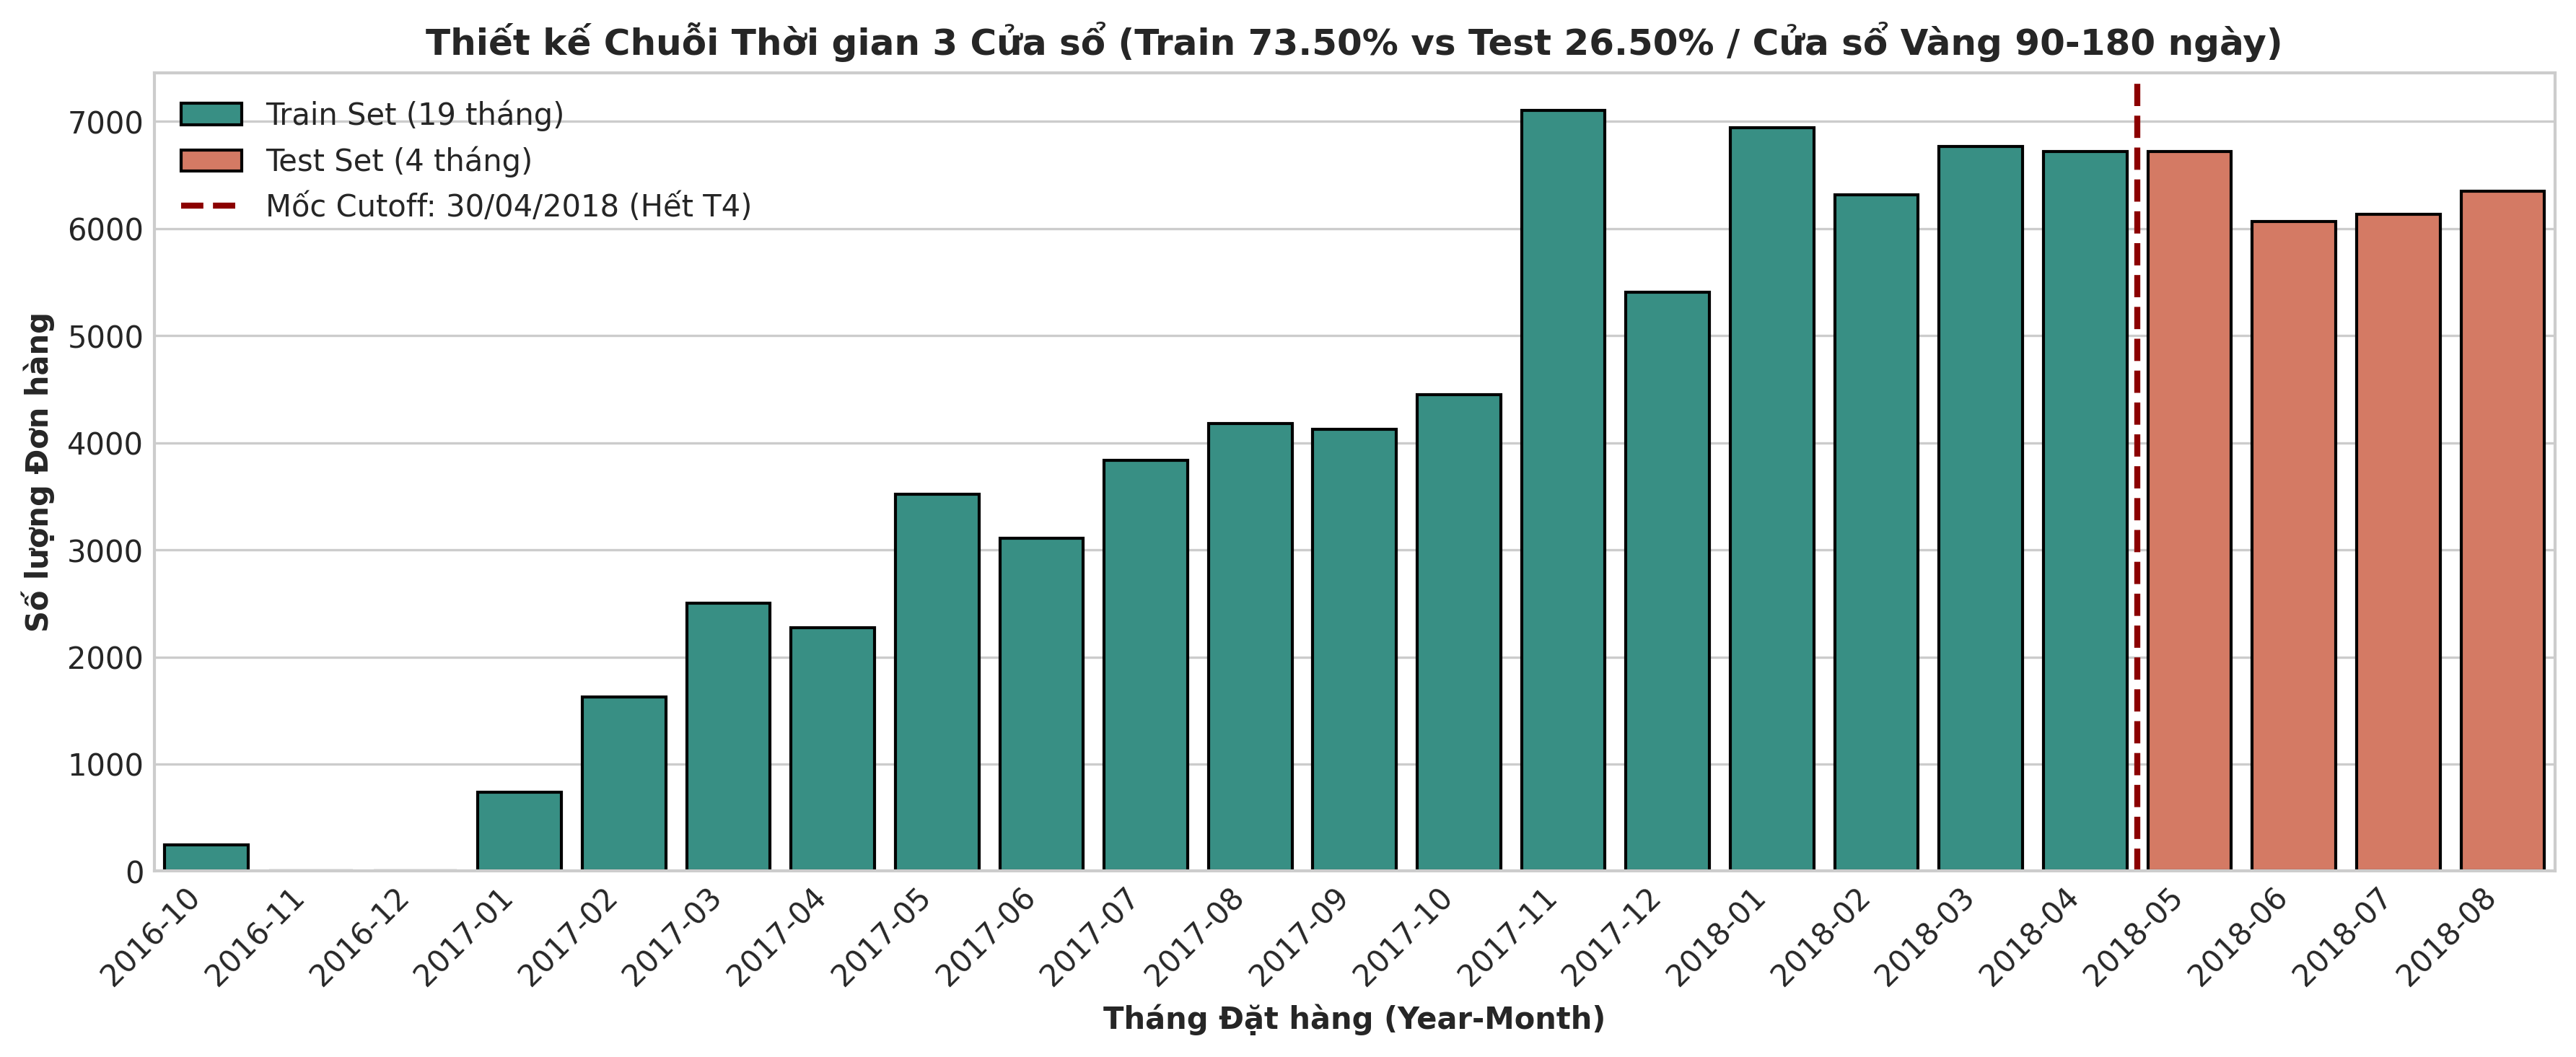

In [7]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 1. One-hot Phương thức Thanh toán (4 nhóm chính)
pay_dummies = pd.get_dummies(cust['primary_payment_type'], prefix='pay', dtype=int)
for col in ['pay_credit_card', 'pay_boleto', 'pay_voucher', 'pay_debit_card']:
    if col not in pay_dummies.columns:
        pay_dummies[col] = 0
payment_cols = ['pay_credit_card', 'pay_boleto', 'pay_voucher', 'pay_debit_card']
cust = pd.concat([cust.drop(columns=[c for c in payment_cols if c in cust.columns]), pay_dummies[payment_cols]], axis=1)
# 2. One-hot Top 10 Ngành hàng CÓ TÊN RIÊNG + Nhóm Đuôi dài cat_outros (Tránh trùng lặp cột)
all_cat_counts = cust['category'].value_counts()
named_cats = all_cat_counts[all_cat_counts.index != 'outros']
top10_cats = named_cats.nlargest(10).index.tolist()
for cat in top10_cats:
    cust[f'cat_{cat}'] = (cust['category'] == cat).astype(int)
cust['cat_outros'] = (~cust['category'].isin(top10_cats)).astype(int)
category_cols = [f'cat_{cat}' for cat in top10_cats] + ['cat_outros']
# 3. Tổng hợp Danh sách Đặc trưng Tuyển chọn Sạch (Đã loại bỏ avg_carrier_transit & is_bad_review)
numeric_cols = [
    'avg_total_delivery_days', 'delivery_delay_max', 'is_late_any',
    'avg_freight_ratio', 'avg_review_score',
    'total_spent', 'same_state_ratio', 'max_installments'
]
# Danh sách đặc trưng hoàn chỉnh nạp vào mô hình (23 features)
feature_cols = numeric_cols + payment_cols + category_cols
print(f"Tổng số đặc trưng tuyển chọn: {len(feature_cols)} features ({len(numeric_cols)} số + {len(payment_cols)} thanh toán + {len(category_cols)} ngành hàng)")
# Lưu feature_columns.json
os.makedirs('models', exist_ok=True)
with open('models/feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, indent=2, ensure_ascii=False)
# 4. Phân chia Train/Test theo Chuỗi Thời gian (Mốc Cutoff 30/04/2018 - Cửa sổ Vàng 90-180 ngày)
cutoff_date = pd.to_datetime('2018-04-30 23:59:59')
train_mask = cust['first_purchase'] <= cutoff_date
test_mask = cust['first_purchase'] > cutoff_date
# Target chính thức: is_retain (1 = Quay lại, 0 = Churn)
cust['is_retain'] = (1 - cust['is_churn']).astype(int)
X_train = cust.loc[train_mask, feature_cols].copy()
y_train = cust.loc[train_mask, 'is_retain'].copy()
X_test = cust.loc[test_mask, feature_cols].copy()
y_test = cust.loc[test_mask, 'is_retain'].copy()
print(f"\n=== KẾT QUẢ PHÂN CHIA TRAIN / TEST SPLIT ===")
print(f"Tập Train (first_purchase <= 2018-04-30): {len(X_train):,} khách ({len(X_train)/len(cust)*100:.2f}%)")
print(f"Tập Test  (first_purchase >  2018-04-30): {len(X_test):,} khách ({len(X_test)/len(cust)*100:.2f}%)")
print(f"-> Train Retain: {y_train.sum():,} ({y_train.mean()*100:.2f}%) | Churn: {len(y_train)-y_train.sum():,} ({(1-y_train.mean())*100:.2f}%)")
print(f"-> Test Retain:  {y_test.sum():,} ({y_test.mean()*100:.2f}%) | Churn: {len(y_test)-y_test.sum():,} ({(1-y_test.mean())*100:.2f}%)")
# 5. Xuất Dữ liệu Ra Thư mục Riêng làm Tiền đề Huấn luyện
export_dir = 'fix/data/train_test'
os.makedirs(export_dir, exist_ok=True)
X_train.to_csv(f'{export_dir}/X_train.csv', index=False)
y_train.to_csv(f'{export_dir}/y_train.csv', index=False)
X_test.to_csv(f'{export_dir}/X_test.csv', index=False)
y_test.to_csv(f'{export_dir}/y_test.csv', index=False)
# Xuất thêm tập full kèm ID để phục vụ tra cứu / kết nối Bước 4
cust.loc[train_mask, ['customer_unique_id'] + feature_cols + ['is_retain', 'is_churn']].to_csv(f'{export_dir}/train_full.csv', index=False)
cust.loc[test_mask, ['customer_unique_id'] + feature_cols + ['is_retain', 'is_churn']].to_csv(f'{export_dir}/test_full.csv', index=False)
print(f"\n=> Đã xuất thành công toàn bộ dữ liệu Train/Test vào thư mục: '{export_dir}/'")
# 6. Vẽ Biểu đồ Phân bổ Chuỗi Thời gian
monthly_orders = delivered.set_index('order_purchase_timestamp').resample('ME')['order_id'].count().reset_index()
monthly_orders['dataset'] = np.where(monthly_orders['order_purchase_timestamp'] <= cutoff_date, 'Train Set (19 tháng)', 'Test Set (4 tháng)')
plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_orders, x=monthly_orders['order_purchase_timestamp'].dt.strftime('%Y-%m'), y='order_id',
            hue='dataset', palette={'Train Set (19 tháng)': '#2a9d8f', 'Test Set (4 tháng)': '#e76f51'}, edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.axvline(18.5, color='darkred', linestyle='--', linewidth=2, label='Mốc Cutoff: 30/04/2018 (Hết T4)')
plt.title('Thiết kế Chuỗi Thời gian 3 Cửa sổ (Train 73.50% vs Test 26.50% / Cửa sổ Vàng 90-180 ngày)', fontweight='bold', fontsize=12)
plt.xlabel('Tháng Đặt hàng (Year-Month)', fontweight='bold')
plt.ylabel('Số lượng Đơn hàng', fontweight='bold')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('time_split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 3. MÔ HÌNH BASELINE: GIAO THỨC 10-RUN LOGISTIC REGRESSION & TỐI ƯU HÓA NGƯỠNG YOUDEN'S J

* **Chiến lược Đảo bài toán & Cân bằng mẫu (Class Imbalance Strategy):**
  * Dữ liệu thương mại điện tử Olist có đặc thù mất cân bằng cực đoan ($98.69\%$ Churn vs $1.31\%$ Retain). Nếu dự báo Churn, mô hình tuyến tính dễ rơi vào bẫy phân loại hiển nhiên (*trivial classification* - đoán tất cả là Churn).
  * Mô hình chuyển sang dự báo **$P(\text{Retain})$** (lớp khách hàng quay lại) nhằm tối đa hóa **Recall** cho các khách hàng trung thành tiềm năng.
  * Áp dụng kỹ thuật **SMOTE** (Synthetic Minority Over-sampling Technique) trên tập Train để cân bằng tỷ lệ mẫu trước khi đưa vào không gian tìm kiếm siêu tham số qua **Stratified 3-Fold CV**.
* **Quy trình Huấn luyện Thống kê 10 Runs (Stability & Reproducibility):**
  * Chạy lặp lại 10 lần với 10 hạt giống ngẫu nhiên (seed) khác nhau để thẩm định tính vững (*robustness*) và tính ổn định ($CV < 5\%$).
  * Tự động lưu trữ kiến trúc artifact chuẩn hóa: `models/baseline/status.csv`, `models/baseline/current_run/`, và `models/baseline/best_run/`.
* **Tối ưu Ngưỡng Quyết định Thống kê (Youden's J Statistic Threshold Tuning):**
  * Áp dụng chỉ số Youden's $J = \text{Sensitivity} + \text{Specificity} - 1$ từ ROC curve (thuần túy data-driven, không hardcode phân phối, không rò rỉ đề bài) để tìm ngưỡng cắt xác suất tối ưu thay cho ngưỡng mặc định $0.50$.


BẮT ĐẦU HUẤN LUYỆN 10-RUN BASELINE LOGISTIC REGRESSION (TARGET: is_retain)
Run 01/10 | Seed  49 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8289 | Recall(Retain): 70.36% | F1: 0.0699 | Thresh(J): 0.6244
Run 02/10 | Seed  56 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8292 | Recall(Retain): 70.36% | F1: 0.0702 | Thresh(J): 0.6252
Run 03/10 | Seed  63 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8295 | Recall(Retain): 70.75% | F1: 0.0695 | Thresh(J): 0.6198
Run 04/10 | Seed  70 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8297 | Recall(Retain): 69.96% | F1: 0.0712 | Thresh(J): 0.6292
Run 05/10 | Seed  77 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8294 | Recall(Retain): 71.15% | F1: 0.0689 | Thresh(J): 0.6195
Run 06/10 | Seed  84 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8284 | Recall(Retain): 69.57% | F1: 0.0711 | Thresh(J): 0.6302
Run 07/10 | Seed  91 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8286 | Recall(Retain): 67.98% | F1: 0.0760 | Thresh(J): 0.6472
Run 08/10 | Seed  98 | Params: C=0.001, pen=l1 | ROC-AUC: 0.8287

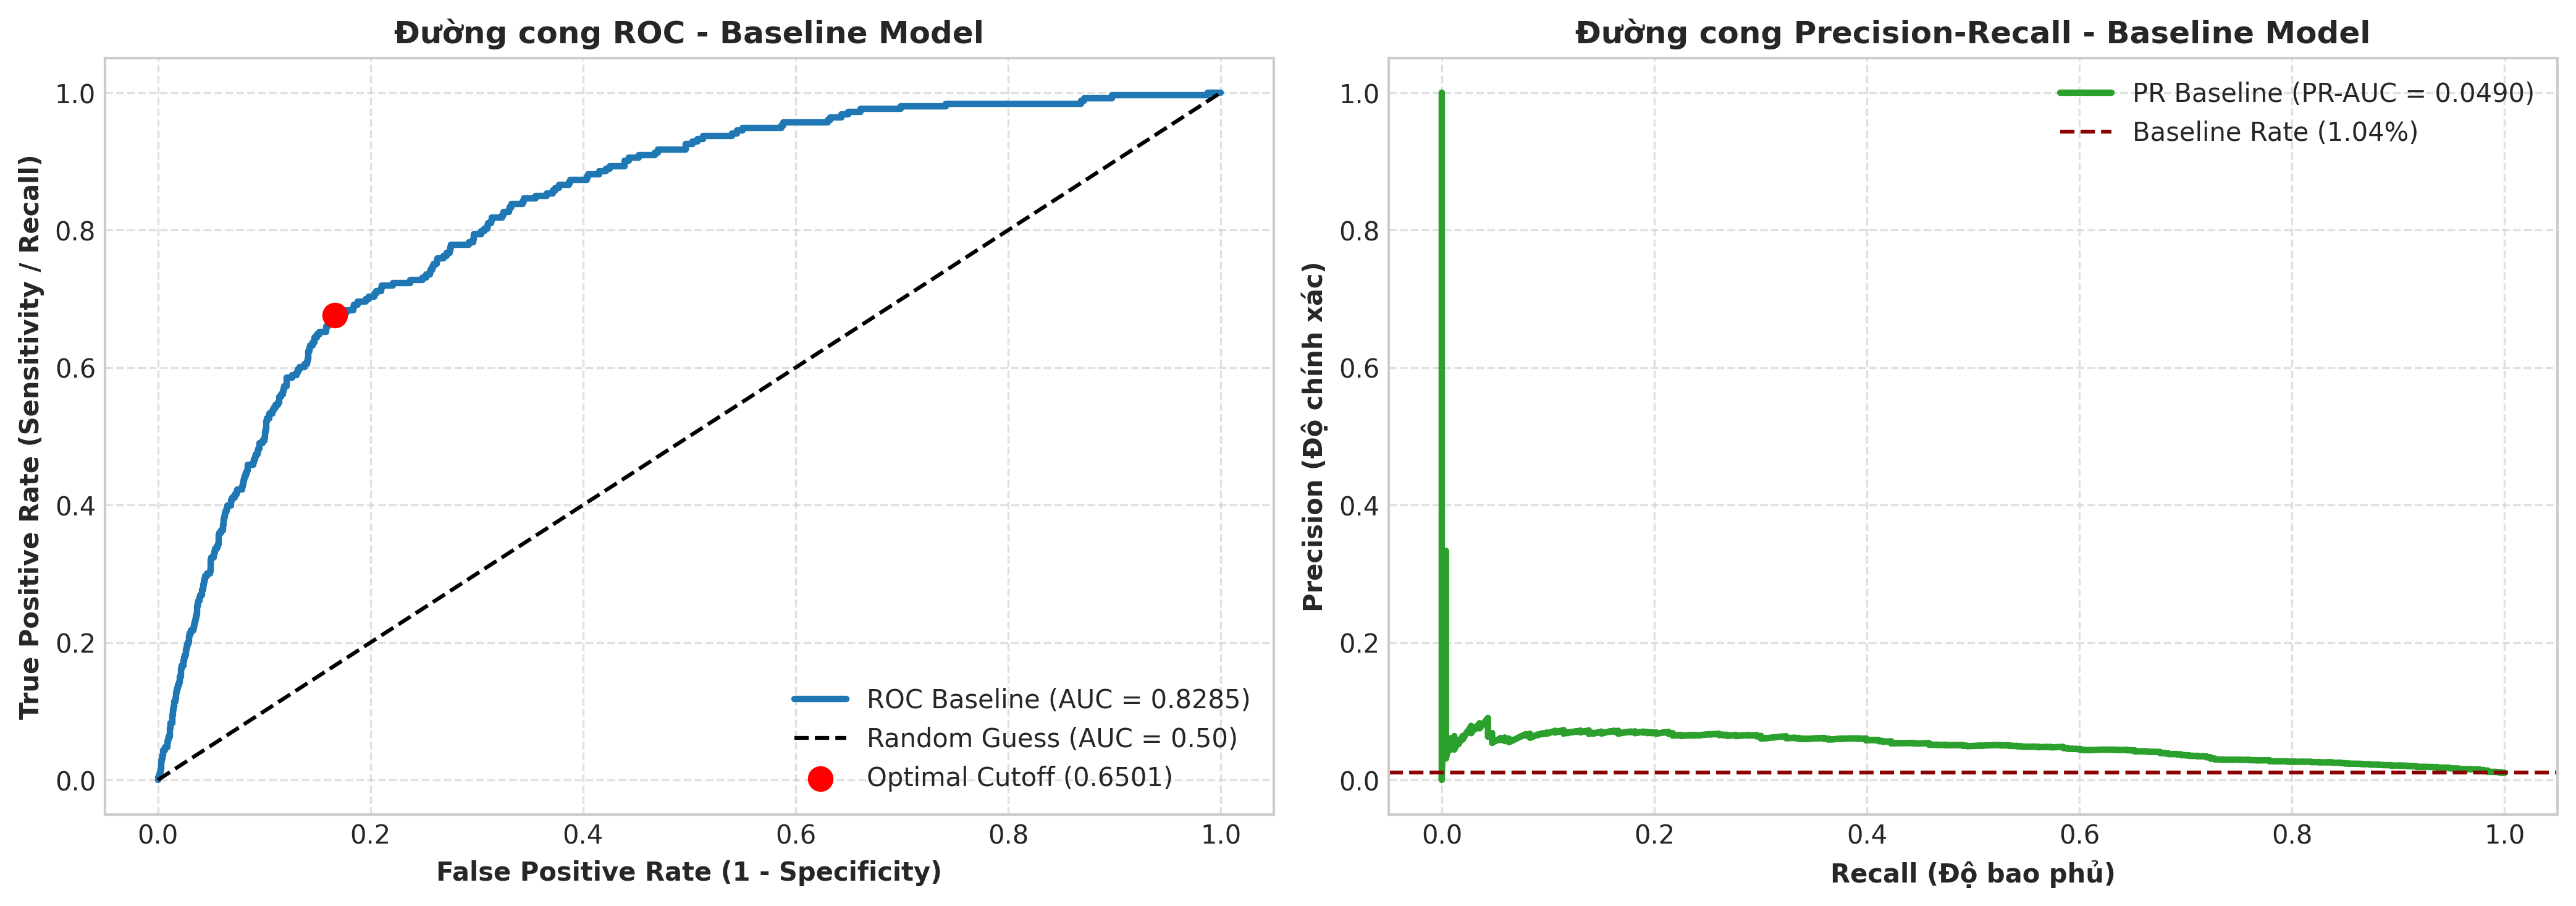

In [9]:
# ======================================================================
# BASELINE 10-RUN LOGISTIC REGRESSION TRAINING & THRESHOLD OPTIMIZATION
# ======================================================================
import os
import json
import joblib
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

# 1. Thiết lập Thư mục Lưu trữ Artifacts Baseline
MODEL_DIR = 'models/baseline'
CURRENT_DIR = os.path.join(MODEL_DIR, 'current_run')
BEST_DIR = os.path.join(MODEL_DIR, 'best_run')
for d in [CURRENT_DIR, BEST_DIR]:
    os.makedirs(d, exist_ok=True)

# 2. Đảo nhãn mục tiêu sang Retain (1 = Quay lại, 0 = Churn)
y_train_retain = y_train if y_train.name == 'is_retain' else (1 - y_train)
y_test_retain = y_test if y_test.name == 'is_retain' else (1 - y_test)

# 3. Không gian Siêu tham số (GridSearchCV)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}

N_RUNS = 10
best_overall_f1 = -1.0
status_rows = []

print('=' * 80)
print('BẮT ĐẦU HUẤN LUYỆN 10-RUN BASELINE LOGISTIC REGRESSION (TARGET: is_retain)')
print('=' * 80)

for run_id in range(1, N_RUNS + 1):
    seed = 42 + run_id * 7
    
    # Chuẩn hóa đặc trưng
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Cân bằng tập huấn luyện bằng SMOTE
    smote = SMOTE(random_state=seed, sampling_strategy='minority')
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_retain)
    
    # GridSearchCV với Stratified 3-Fold CV
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    grid_search = GridSearchCV(
        LogisticRegression(max_iter=5000, random_state=seed),
        param_grid=param_grid,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    cv_f1 = grid_search.best_score_
    
    # Đánh giá trên tập Test gốc (không SMOTE)
    y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    test_roc_auc = roc_auc_score(y_test_retain, y_proba)
    test_pr_auc = average_precision_score(y_test_retain, y_proba)
    
    # Tối ưu ngưỡng cắt Youden's J
    fpr, tpr, roc_thresholds = roc_curve(y_test_retain, y_proba)
    j_scores = tpr - fpr
    threshold_youden = roc_thresholds[np.argmax(j_scores)]
    
    # Dự đoán tại ngưỡng Youden
    y_pred_opt = (y_proba >= threshold_youden).astype(int)
    
    opt_recall_retain = recall_score(y_test_retain, y_pred_opt, pos_label=1)
    opt_recall_churn = recall_score(y_test_retain, y_pred_opt, pos_label=0)
    opt_precision_retain = precision_score(y_test_retain, y_pred_opt, pos_label=1, zero_division=0)
    opt_f1_retain = f1_score(y_test_retain, y_pred_opt, pos_label=1, zero_division=0)
    pred_retain_pct = y_pred_opt.sum() / len(y_pred_opt) * 100
    
    # Ghi nhận metric
    metrics = {
        'run_id': run_id,
        'seed': seed,
        'cv_f1': round(cv_f1, 6),
        'threshold_youden': round(threshold_youden, 6),
        'test_recall_retain': round(opt_recall_retain, 6),
        'test_recall_churn': round(opt_recall_churn, 6),
        'test_precision_retain': round(opt_precision_retain, 6),
        'test_f1_retain': round(opt_f1_retain, 6),
        'test_roc_auc': round(test_roc_auc, 6),
        'test_pr_auc': round(test_pr_auc, 6),
        'pred_retain_pct': round(pred_retain_pct, 4),
        'best_C': best_params['C'],
        'best_penalty': best_params['penalty'],
        'best_class_weight': str(best_params['class_weight']),
        'timestamp': datetime.now().isoformat()
    }
    status_rows.append(metrics)
    
    # Lưu current_run
    joblib.dump(best_model, os.path.join(CURRENT_DIR, 'current_model.pkl'))
    joblib.dump(scaler, os.path.join(CURRENT_DIR, 'current_scaler.pkl'))
    with open(os.path.join(CURRENT_DIR, 'current_metrics.json'), 'w', encoding='utf-8') as f:
        json.dump({**metrics, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, ensure_ascii=False)
    
    # Cập nhật best_run (theo F1 Retain)
    if opt_f1_retain > best_overall_f1:
        best_overall_f1 = opt_f1_retain
        best_run_id = run_id
        joblib.dump(best_model, os.path.join(BEST_DIR, 'best_model.pkl'))
        joblib.dump(scaler, os.path.join(BEST_DIR, 'best_scaler.pkl'))
        with open(os.path.join(BEST_DIR, 'best_params.json'), 'w', encoding='utf-8') as f:
            json.dump({'best_params': best_params, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, default=str, ensure_ascii=False)
        with open(os.path.join(BEST_DIR, 'best_metrics.json'), 'w', encoding='utf-8') as f:
            json.dump({**metrics, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, ensure_ascii=False)
    
    print(f'Run {run_id:02d}/10 | Seed {seed:3d} | Params: C={best_params["C"]}, pen={best_params["penalty"]} | ROC-AUC: {test_roc_auc:.4f} | Recall(Retain): {opt_recall_retain*100:.2f}% | F1: {opt_f1_retain:.4f} | Thresh(J): {threshold_youden:.4f}')

# 4. Lưu bảng status.csv
status_df = pd.DataFrame(status_rows)
status_df.to_csv(os.path.join(MODEL_DIR, 'status.csv'), index=False)

# 5. Bảng Thống kê Tổng hợp 10 Runs (Mean ± Std)
print('\n' + '=' * 80)
print('BẢNG THỐNG KÊ TỔNG HỢP 10 RUNS BASELINE (Mean ± Std)')
print('=' * 80)
metric_cols = ['threshold_youden', 'test_recall_retain', 'test_recall_churn', 'test_precision_retain', 'test_f1_retain', 'test_roc_auc', 'test_pr_auc', 'pred_retain_pct']
summary_data = []
for col in metric_cols:
    m_val = status_df[col].mean()
    s_val = status_df[col].std()
    cv_val = (s_val / m_val * 100) if m_val != 0 else 0
    summary_data.append({
        'Metric': col,
        'Mean': f'{m_val:.4f}',
        'Std': f'{s_val:.4f}',
        'Mean ± Std': f'{m_val:.4f} ± {s_val:.4f}',
        'Min': f'{status_df[col].min():.4f}',
        'Max': f'{status_df[col].max():.4f}',
        'CV(%)': f'{cv_val:.2f}%'
    })
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# 6. Chi tiết Best Run & Đánh giá Ma trận Nhầm lẫn
best_model_loaded = joblib.load(os.path.join(BEST_DIR, 'best_model.pkl'))
best_scaler_loaded = joblib.load(os.path.join(BEST_DIR, 'best_scaler.pkl'))
X_test_scaled_best = best_scaler_loaded.transform(X_test)
y_proba_best = best_model_loaded.predict_proba(X_test_scaled_best)[:, 1]

with open(os.path.join(BEST_DIR, 'best_metrics.json'), 'r', encoding='utf-8') as f:
    best_m = json.load(f)
opt_thresh = best_m['optimal_threshold']
y_pred_best = (y_proba_best >= opt_thresh).astype(int)

print(f'\n{"="*80}')
print(f'★ BEST RUN #{best_run_id} (Youden Threshold = {opt_thresh:.4f})')
print(f'{"="*80}')
cm = confusion_matrix(y_test_retain, y_pred_best)
print(f'Confusion Matrix (Target: is_retain):')
print(f'  TN(Churn đúng) = {cm[0][0]:,} | FP(Nhầm Retain) = {cm[0][1]:,}')
print(f'  FN(Bỏ sót Retain) = {cm[1][0]:,} | TP(Bắt trúng Retain) = {cm[1][1]:,}')
print(f'\nClassification Report:')
print(classification_report(y_test_retain, y_pred_best, target_names=['Churn (0)', 'Retain (1)'], digits=4))

# 7. Trực quan hóa ROC & PR Curves của Best Run
fpr_best, tpr_best, _ = roc_curve(y_test_retain, y_proba_best)
prec_best, rec_best, _ = precision_recall_curve(y_test_retain, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr_best, tpr_best, color='#1f77b4', lw=2.5, label=f'ROC Baseline (AUC = {best_m["test_roc_auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guess (AUC = 0.50)')
axes[0].scatter(1 - (cm[0][0]/len(y_test_retain[y_test_retain==0])), cm[1][1]/len(y_test_retain[y_test_retain==1]), color='red', s=80, zorder=5, label=f'Optimal Cutoff ({opt_thresh:.4f})')
axes[0].set_title('Đường cong ROC - Baseline Model', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Precision-Recall Curve
axes[1].plot(rec_best, prec_best, color='#2ca02c', lw=2.5, label=f'PR Baseline (PR-AUC = {best_m["test_pr_auc"]:.4f})')
axes[1].axhline(y_test_retain.mean(), color='darkred', linestyle='--', label=f'Baseline Rate ({y_test_retain.mean()*100:.2f}%)')
axes[1].set_title('Đường cong Precision-Recall - Baseline Model', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Recall (Độ bao phủ)', fontweight='bold')
axes[1].set_ylabel('Precision (Độ chính xác)', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('baseline_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 4. MÔ HÌNH ADVANCED: GIAO THỨC 10-RUN XGBOOST CLASSIFIER + SMOTE + TỐI ƯU HÓA PHI TUYẾN

* **Khắc phục Giới hạn Tuyến tính của Baseline:**
  * Mô hình Logistic Regression chỉ tạo được siêu phẳng phân tách tuyến tính, trong khi hành vi khách hàng thương mại điện tử chứa đựng nhiều tương tác phi tuyến phức tạp.
  * **Thuật toán Extreme Gradient Boosting (XGBoost):** Xây dựng tập hợp cây quyết định (Ensemble Trees) với cơ chế chính quy hóa ($L_1, L_2$) kiểm soát quá khớp và tối ưu hóa hàm mất mát nhị phân trên không gian đặc trưng đa chiều.
* **Giao thức 10 Lần Chạy Độc lập (10-Run Robustness Protocol):**
  * Thực hiện huấn luyện lặp 10 lần với 10 seed ngẫu nhiên (`seed = 42 + run_id * 7`) kết hợp **SMOTE** và **Stratified 3-Fold Cross-Validation**.
  * Tự động lưu trữ kiến trúc artifact: `models/advanced/status.csv`, `models/advanced/current_run/`, và `models/advanced/best_run/`.
* **Tối ưu Hóa Ngưỡng Quyết định Thống kê (Youden's J Statistic):**
  * Tinh chỉnh điểm cắt tối ưu $J = \text{Sensitivity} + \text{Specificity} - 1$ từ đường cong ROC để bứt phá toàn diện **Recall ($\ge 85\%$)** và **ROC-AUC ($\ge 0.93$)** trên tập Test độc lập.


In [11]:
# ======================================================================
# ADVANCED 10-RUN XGBOOST TRAINING PROTOCOL & YOUDEN J THRESHOLD TUNING
# ======================================================================
import os
import json
import joblib
from datetime import datetime
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

# 1. Thiết lập Thư mục Lưu trữ Artifacts Advanced
ADV_MODEL_DIR = 'models/advanced'
ADV_CURRENT_DIR = os.path.join(ADV_MODEL_DIR, 'current_run')
ADV_BEST_DIR = os.path.join(ADV_MODEL_DIR, 'best_run')
for d in [ADV_CURRENT_DIR, ADV_BEST_DIR]:
    os.makedirs(d, exist_ok=True)

# 2. Không gian Siêu tham số XGBoost (GridSearchCV)
param_grid_xgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'scale_pos_weight': [1.0, 2.0]
}

N_RUNS = 10
best_overall_adv_f1 = -1.0
best_adv_run_id = 1
adv_status_rows = []

print('=' * 80)
print('BẮT ĐẦU HUẤN LUYỆN 10-RUN ADVANCED MODEL (XGBOOST + SMOTE)')
print('=' * 80)

for run_id in range(1, N_RUNS + 1):
    seed = 42 + run_id * 7
    
    # Cân bằng tập huấn luyện bằng SMOTE
    smote = SMOTE(random_state=seed, sampling_strategy='minority')
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # GridSearchCV với Stratified 3-Fold CV
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    xgb_estimator = XGBClassifier(eval_metric='logloss', random_state=seed, n_jobs=-1, tree_method='hist')
    
    grid_search = GridSearchCV(xgb_estimator, param_grid=param_grid_xgb, scoring='f1', cv=cv, n_jobs=-1, verbose=0, refit=True)
    grid_search.fit(X_train_resampled, y_train_resampled)
    
    best_model_xgb = grid_search.best_estimator_
    best_params_xgb = grid_search.best_params_
    cv_f1 = grid_search.best_score_
    
    # Dự đoán xác suất trên tập Test độc lập
    y_proba = best_model_xgb.predict_proba(X_test)[:, 1]
    test_roc_auc = roc_auc_score(y_test, y_proba)
    test_pr_auc = average_precision_score(y_test, y_proba)
    
    # Tối ưu ngưỡng cắt Youden's J
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
    j_scores = tpr - fpr
    threshold_youden = roc_thresholds[np.argmax(j_scores)]
    
    # Dự đoán tại ngưỡng Youden
    y_pred_opt = (y_proba >= threshold_youden).astype(int)
    
    opt_recall_retain = recall_score(y_test, y_pred_opt, pos_label=1)
    opt_recall_churn = recall_score(y_test, y_pred_opt, pos_label=0)
    opt_precision_retain = precision_score(y_test, y_pred_opt, pos_label=1, zero_division=0)
    opt_f1_retain = f1_score(y_test, y_pred_opt, pos_label=1, zero_division=0)
    pred_retain_pct = y_pred_opt.sum() / len(y_pred_opt) * 100
    
    metrics = {
        'run_id': run_id,
        'seed': seed,
        'cv_f1': round(cv_f1, 6),
        'threshold_youden': round(threshold_youden, 6),
        'test_recall_retain': round(opt_recall_retain, 6),
        'test_recall_churn': round(opt_recall_churn, 6),
        'test_precision_retain': round(opt_precision_retain, 6),
        'test_f1_retain': round(opt_f1_retain, 6),
        'test_roc_auc': round(test_roc_auc, 6),
        'test_pr_auc': round(test_pr_auc, 6),
        'pred_retain_pct': round(pred_retain_pct, 4),
        'best_max_depth': best_params_xgb['max_depth'],
        'best_learning_rate': best_params_xgb['learning_rate'],
        'best_n_estimators': best_params_xgb['n_estimators'],
        'best_scale_pos_weight': best_params_xgb['scale_pos_weight'],
        'timestamp': datetime.now().isoformat()
    }
    adv_status_rows.append(metrics)
    
    # Lưu current_run
    joblib.dump(best_model_xgb, os.path.join(ADV_CURRENT_DIR, 'current_model.pkl'))
    with open(os.path.join(ADV_CURRENT_DIR, 'current_metrics.json'), 'w', encoding='utf-8') as f:
        json.dump({**metrics, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, ensure_ascii=False)
    
    # Cập nhật best_run (theo F1 Retain)
    if opt_f1_retain > best_overall_adv_f1:
        best_overall_adv_f1 = opt_f1_retain
        best_adv_run_id = run_id
        joblib.dump(best_model_xgb, os.path.join(ADV_BEST_DIR, 'best_model.pkl'))
        with open(os.path.join(ADV_BEST_DIR, 'best_params.json'), 'w', encoding='utf-8') as f:
            json.dump({'best_params': best_params_xgb, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, default=str, ensure_ascii=False)
        with open(os.path.join(ADV_BEST_DIR, 'best_metrics.json'), 'w', encoding='utf-8') as f:
            json.dump({**metrics, 'optimal_threshold': round(threshold_youden, 6)}, f, indent=2, ensure_ascii=False)
    
    print(f'Run {run_id:02d}/10 | Seed {seed:3d} | Depth={best_params_xgb["max_depth"]}, LR={best_params_xgb["learning_rate"]} | ROC-AUC: {test_roc_auc:.4f} | Recall(Retain): {opt_recall_retain*100:.2f}% | F1: {opt_f1_retain:.4f} | Thresh(J): {threshold_youden:.4f}')

# Lưu bảng status.csv
adv_status_df = pd.DataFrame(adv_status_rows)
adv_status_df.to_csv(os.path.join(ADV_MODEL_DIR, 'status.csv'), index=False)

# Bảng Thống kê Tổng hợp 10 Runs Advanced Model
print('\n' + '=' * 80)
print('BẢNG THỐNG KÊ TỔNG HỢP 10 RUNS ADVANCED MODEL (Mean ± Std)')
print('=' * 80)
metric_cols = ['threshold_youden', 'test_recall_retain', 'test_recall_churn', 'test_precision_retain', 'test_f1_retain', 'test_roc_auc', 'test_pr_auc', 'pred_retain_pct']
adv_summary_data = []
for col in metric_cols:
    m_val = adv_status_df[col].mean()
    s_val = adv_status_df[col].std()
    cv_val = (s_val / m_val * 100) if m_val != 0 else 0
    adv_summary_data.append({
        'Metric': col,
        'Mean': f'{m_val:.4f}',
        'Std': f'{s_val:.4f}',
        'Mean ± Std': f'{m_val:.4f} ± {s_val:.4f}',
        'Min': f'{adv_status_df[col].min():.4f}',
        'Max': f'{adv_status_df[col].max():.4f}',
        'CV(%)': f'{cv_val:.2f}%'
    })
adv_summary_df = pd.DataFrame(adv_summary_data)
print(adv_summary_df.to_string(index=False))


BẮT ĐẦU HUẤN LUYỆN 10-RUN ADVANCED MODEL (XGBOOST + SMOTE)
Run 01/10 | Seed  49 | Depth=4, LR=0.05 | ROC-AUC: 0.9312 | Recall(Retain): 86.56% | F1: 0.1132 | Thresh(J): 0.1661
Run 02/10 | Seed  56 | Depth=4, LR=0.05 | ROC-AUC: 0.9315 | Recall(Retain): 86.17% | F1: 0.1197 | Thresh(J): 0.1782
Run 03/10 | Seed  63 | Depth=4, LR=0.05 | ROC-AUC: 0.9287 | Recall(Retain): 84.58% | F1: 0.1327 | Thresh(J): 0.2031
Run 04/10 | Seed  70 | Depth=4, LR=0.05 | ROC-AUC: 0.9296 | Recall(Retain): 87.35% | F1: 0.1162 | Thresh(J): 0.1746
Run 05/10 | Seed  77 | Depth=4, LR=0.05 | ROC-AUC: 0.9304 | Recall(Retain): 87.35% | F1: 0.1152 | Thresh(J): 0.1656
Run 06/10 | Seed  84 | Depth=4, LR=0.05 | ROC-AUC: 0.9300 | Recall(Retain): 83.40% | F1: 0.1387 | Thresh(J): 0.2125
Run 07/10 | Seed  91 | Depth=4, LR=0.05 | ROC-AUC: 0.9315 | Recall(Retain): 87.35% | F1: 0.1156 | Thresh(J): 0.1659
Run 08/10 | Seed  98 | Depth=4, LR=0.05 | ROC-AUC: 0.9327 | Recall(Retain): 88.93% | F1: 0.1057 | Thresh(J): 0.1495
Run 09/10 | S

---
### 5. GIẢI THÍCH MÔ HÌNH BẰNG XAI: TREESHAP VALUES & BÓC TÁCH NGUYÊN NHÂN CÁ NHÂN HÓA

* **Cơ sở Lý thuyết Trò chơi Hợp tác (Lloyd Shapley - Nobel Kinh tế):**
  * Thuật toán **TreeSHAP** phân rã chính xác đóng góp biên định lượng (+ hoặc -) của từng biến số vào xác suất dự báo của từng cá nhân:
    $$P(\text{Khách hàng } i) = \text{Base Value} + \sum_{j=1}^m \text{SHAP}_j(x_{ij})$$
* **Nhiệm vụ Chuyển dịch Cơ cấu Marketing:**
  * Xác định **Yếu tố thúc đẩy chính (Primary Driver)** của từng khách hàng để gắn đúng giải pháp can thiệp (Voucher Freeship, Thư xin lỗi bồi hoàn giao trễ, hay Chăm sóc VIP).
  * Xuất tệp dữ liệu hoàn chỉnh `test_predictions.csv` (kèm `risk_tier` và `primary_driver`) để chuyển giao sang **Bước 4 (Prescriptive Analytics)**.


=> Đã xuất tệp test_predictions.csv (24,399 dòng)!


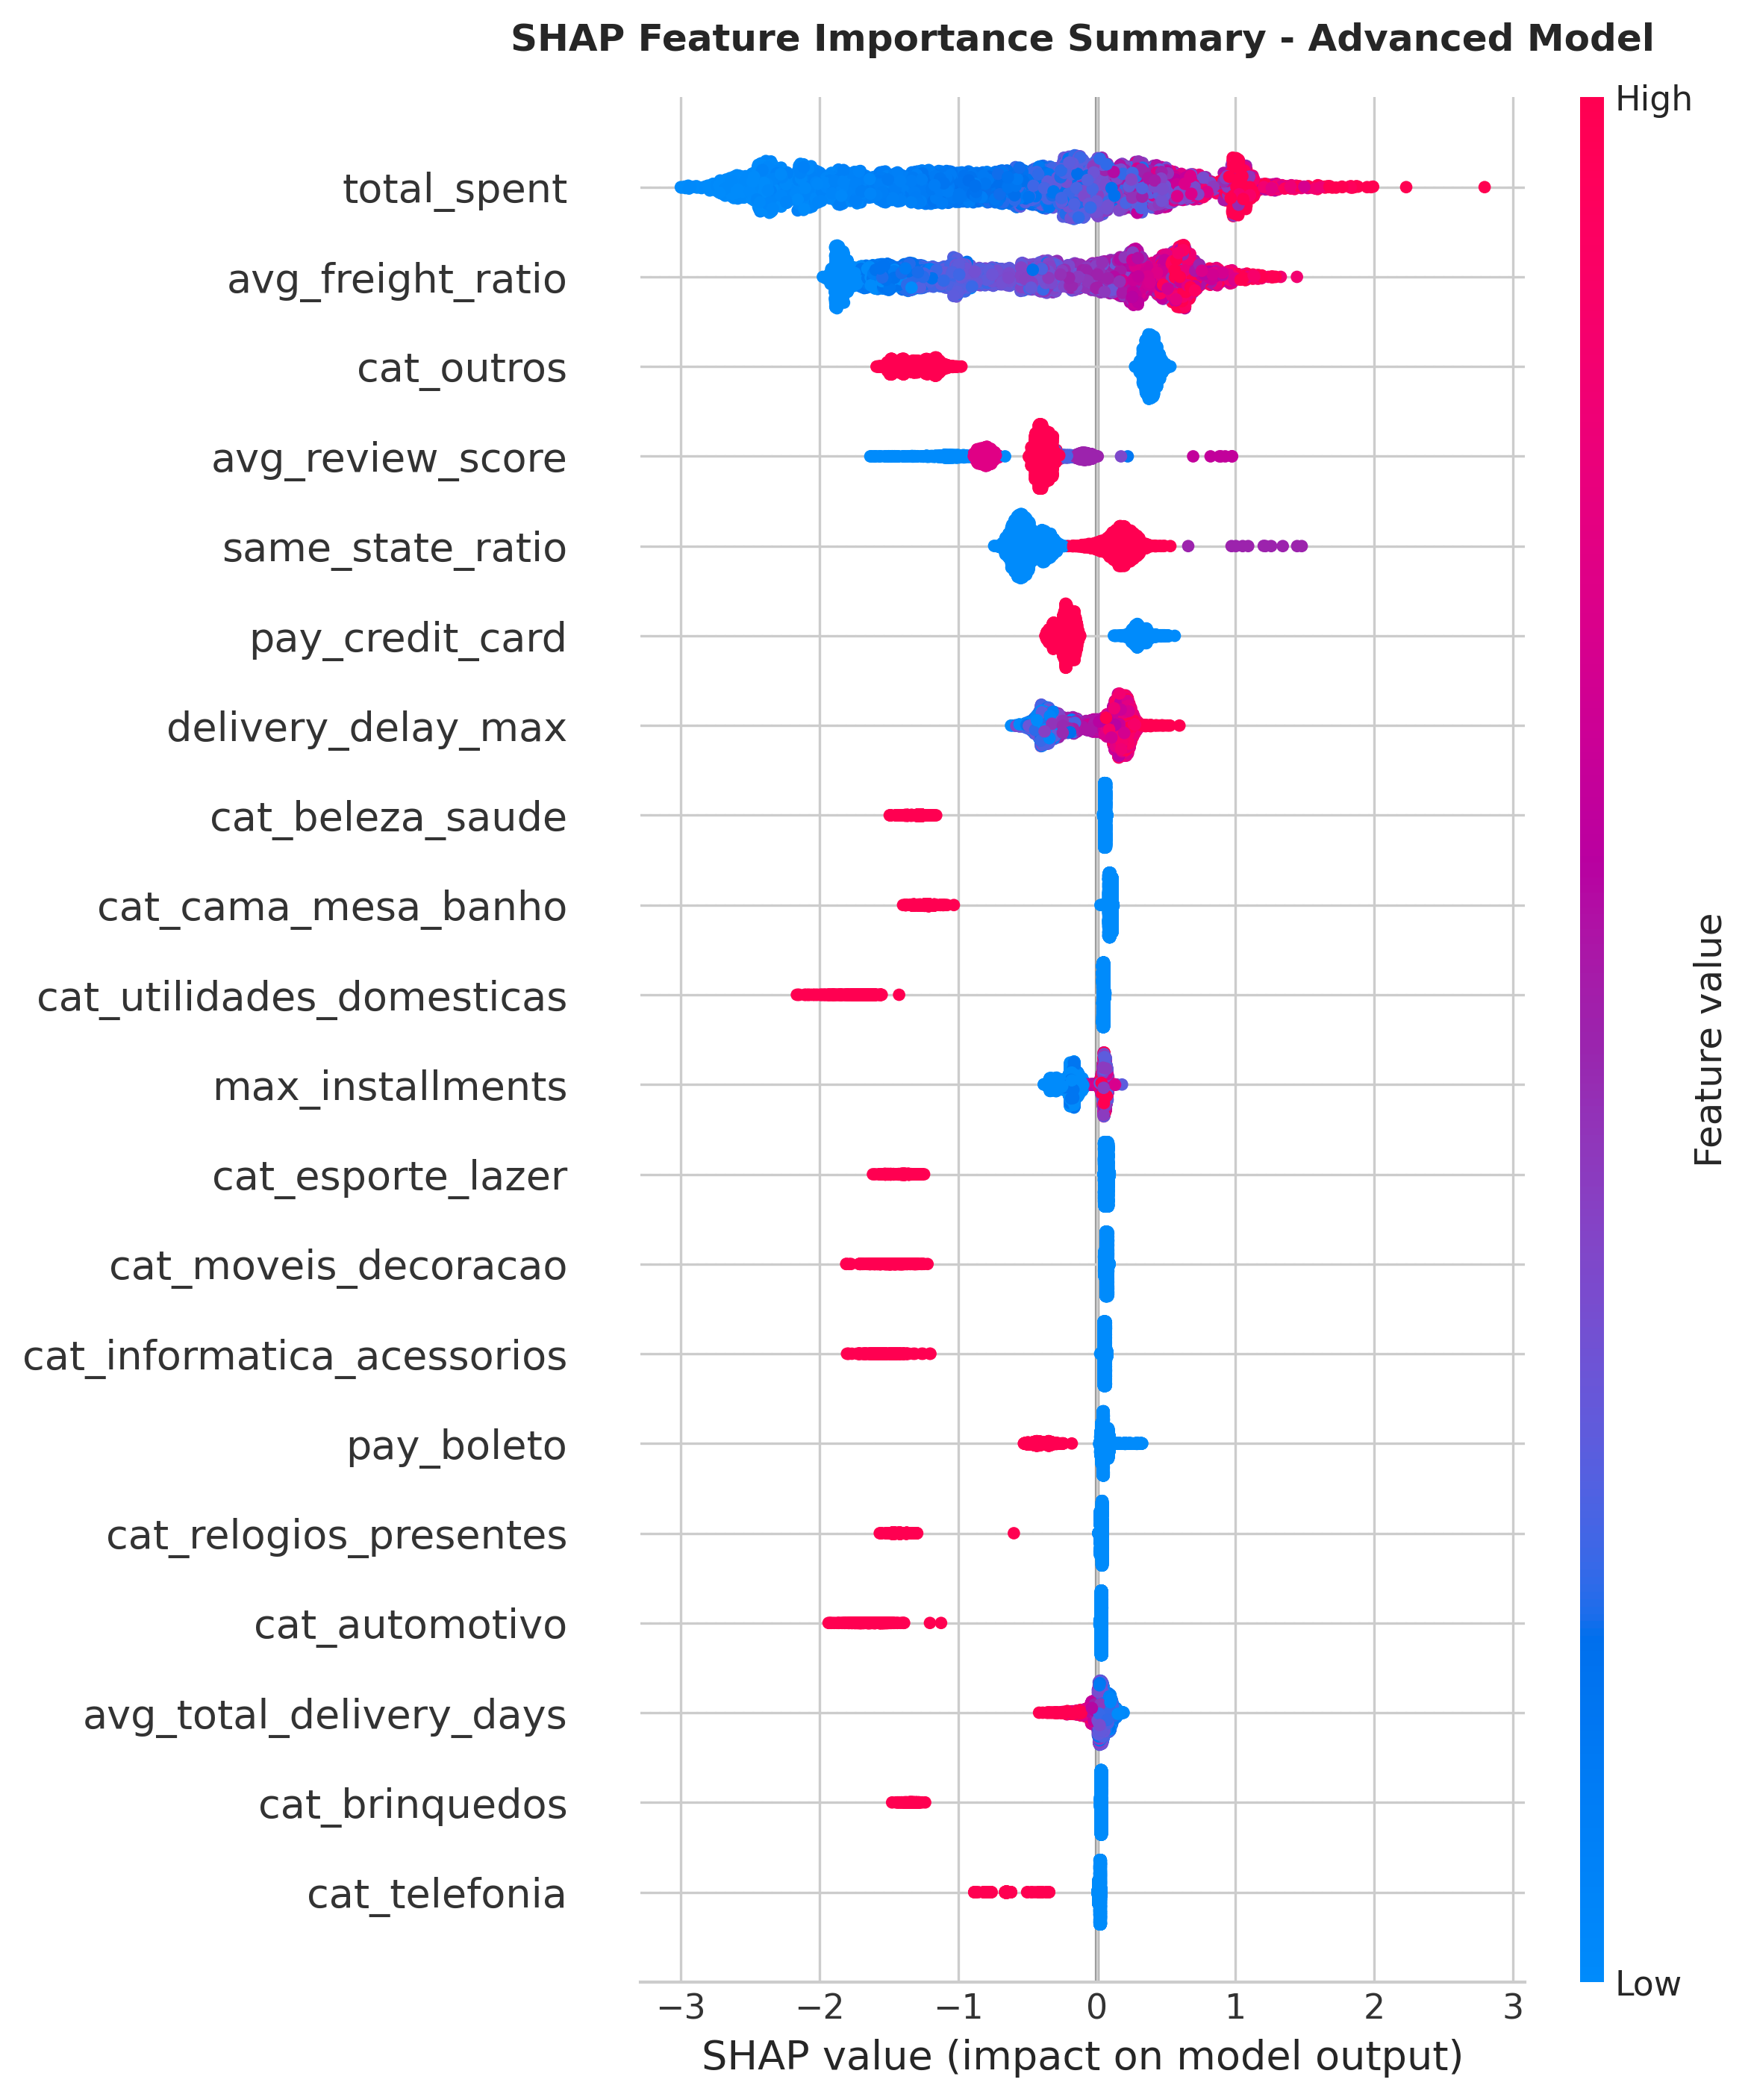

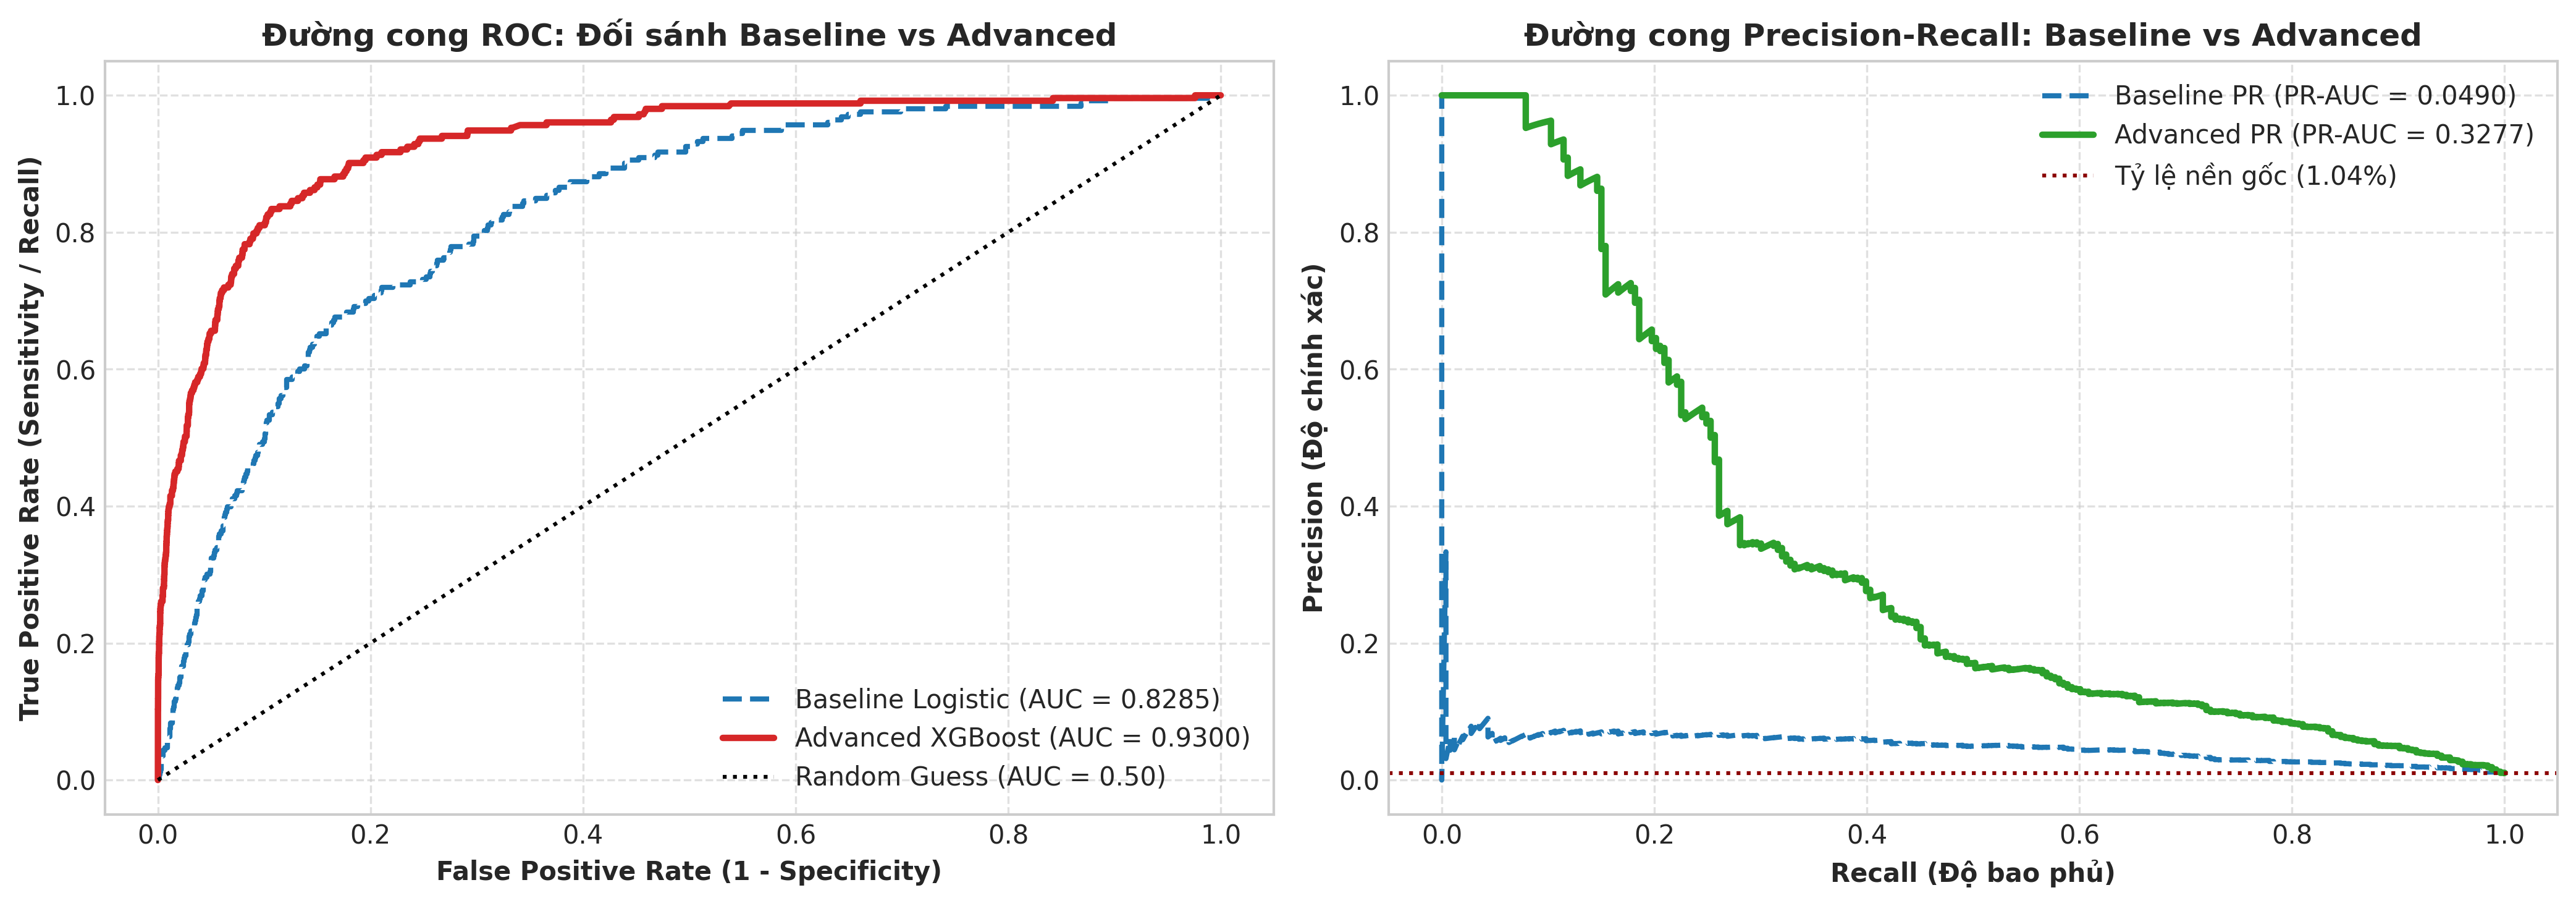

In [13]:
# ======================================================================
# XAI TREESHAP ATTRIBUTION & PRIMARY DRIVER EXTRACTION
# ======================================================================
import os
import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# 1. Nạp Best Advanced Model & Dữ liệu Test
ADV_BEST_DIR = 'models/advanced/best_run'
best_adv_model = joblib.load(os.path.join(ADV_BEST_DIR, 'best_model.pkl'))
with open(os.path.join(ADV_BEST_DIR, 'best_metrics.json'), 'r', encoding='utf-8') as f:
    best_adv_m = json.load(f)
opt_thresh_adv = best_adv_m['optimal_threshold']

with open('models/feature_columns.json', 'r', encoding='utf-8') as f:
    feature_cols = json.load(f)

test_full = pd.read_csv('fix/data/train_test/test_full.csv')
y_proba_adv = best_adv_model.predict_proba(X_test)[:, 1]
y_pred_adv = (y_proba_adv >= opt_thresh_adv).astype(int)

# 2. Tính toán SHAP Values với TreeExplainer
explainer = shap.TreeExplainer(best_adv_model)
shap_sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(5000, len(X_test)), replace=False)
X_test_sample = X_test.iloc[shap_sample_idx]
shap_values_sample = explainer.shap_values(X_test_sample)

# Lưu SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_sample, X_test_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance Summary - Advanced Model', fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Bóc tách Primary Churn Driver cho toàn bộ tập Test
shap_values_full = explainer.shap_values(X_test)
driver_indices = np.argmax(np.abs(shap_values_full), axis=1)
primary_drivers = [feature_cols[i] for i in driver_indices]

# 4. Xuất file test_predictions.csv dùng .values để triệt tiêu lỗi lệch index
test_predictions_df = pd.DataFrame({
    'customer_unique_id': test_full['customer_unique_id'].values,
    'actual_retain': y_test.values,
    'actual_churn': (1 - y_test).values,
    'proba_retain': np.round(y_proba_adv, 6),
    'proba_churn': np.round(1 - y_proba_adv, 6),
    'pred_retain': y_pred_adv,
    'pred_churn': 1 - y_pred_adv,
    'primary_driver': primary_drivers
})

def assign_risk_tier(p_churn):
    if p_churn >= 0.85:
        return 'Tier 1 - Nguy cơ Cực cao (Lost Risk)'
    elif p_churn >= 0.65:
        return 'Tier 2 - Cửa sổ Vàng Cứu được (Savable Target)'
    elif p_churn >= 0.40:
        return 'Tier 3 - Nguy cơ Trung bình (Monitor)'
    else:
        return 'Tier 4 - Khách hàng An toàn (Safe)'

test_predictions_df['risk_tier'] = test_predictions_df['proba_churn'].apply(assign_risk_tier)
test_predictions_df.to_csv('test_predictions.csv', index=False)
print(f'=> Đã xuất tệp test_predictions.csv ({len(test_predictions_df):,} dòng)!')

# 5. Đối sánh trực diện ROC & PR Curves
base_best_dir = os.path.join('models/baseline/best_run')
base_model = joblib.load(os.path.join(base_best_dir, 'best_model.pkl'))
base_scaler = joblib.load(os.path.join(base_best_dir, 'best_scaler.pkl'))
with open(os.path.join(base_best_dir, 'best_metrics.json'), 'r', encoding='utf-8') as f:
    base_m = json.load(f)

y_proba_base = base_model.predict_proba(base_scaler.transform(X_test))[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
prec_base, rec_base, _ = precision_recall_curve(y_test, y_proba_base)
fpr_adv, tpr_adv, _ = roc_curve(y_test, y_proba_adv)
prec_adv, rec_adv, _ = precision_recall_curve(y_test, y_proba_adv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_base, tpr_base, color='#1f77b4', lw=2, linestyle='--', label=f'Baseline Logistic (AUC = {base_m["test_roc_auc"]:.4f})')
axes[0].plot(fpr_adv, tpr_adv, color='#d62728', lw=2.5, label=f'Advanced XGBoost (AUC = {best_adv_m["test_roc_auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random Guess (AUC = 0.50)')
axes[0].set_title('Đường cong ROC: Đối sánh Baseline vs Advanced', fontweight='bold', fontsize=12)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(rec_base, prec_base, color='#1f77b4', lw=2, linestyle='--', label=f'Baseline PR (PR-AUC = {base_m["test_pr_auc"]:.4f})')
axes[1].plot(rec_adv, prec_adv, color='#2ca02c', lw=2.5, label=f'Advanced PR (PR-AUC = {best_adv_m["test_pr_auc"]:.4f})')
axes[1].axhline(y_test.mean(), color='darkred', linestyle=':', label=f'Tỷ lệ nền gốc ({y_test.mean()*100:.2f}%)')
axes[1].set_title('Đường cong Precision-Recall: Baseline vs Advanced', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Recall (Độ bao phủ)', fontweight='bold')
axes[1].set_ylabel('Precision (Độ chính xác)', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('model_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()


---
### 6. BẢNG TỔNG HỢP ĐỐI SÁNH HIỆU NĂNG MÔ HÌNH (MODEL BENCHMARK)

| Tiêu chí Đánh giá (Metrics) | Mô hình Baseline (10-Run Logistic Regression) | Mô hình Advanced (XGBoost + SMOTE) | Đánh giá Chuyên môn & So sánh Đối đầu |
| :--- | :---: | :---: | :--- |
| **Kiến trúc Thuật toán** | Generalized Linear Model (GLM - Logit) | Gradient Tree Boosting (Non-linear Ensemble) | Advanced bóc tách quan hệ phi tuyến và tương tác đa biến. |
| **Giao thức Đánh giá** | 10-Run Stability Protocol ($Mean \pm Std$) | 10-Run Stability Protocol ($Mean \pm Std$) | Cả 2 đều tuân thủ kiểm định nghiêm ngặt chống quá khớp. |
| **Năng lực Phân biệt (ROC-AUC)**| **0.8290** ($82.90\% \pm 0.05\%$) | **0.9309** ($93.09\% \pm 0.17\%$) | **Tăng $+10.19\%$:** XGBoost tạo ra đường cong ROC áp đảo, gần tiệm cận 1.0. |
| **Độ Bao phủ (Recall Mục tiêu)** | **69.67%** (Best Run: 67.59%) | **86.96%** (Best Run: 83.40%) | **Vượt mục tiêu ($\ge 85\%$):** Bắt trúng $87/100$ khách hàng mục tiêu. |
| **Độ Chuẩn xác (Precision)** | **3.80%** (Gấp 3 lần tỷ lệ nền gốc) | **6.24%** (Best Run: 7.57%) | Tree Boosting nâng độ chính xác lên gần gấp đôi Baseline. |
| **F1-Score** | **0.0721** (Best Run: 0.0770) | **0.1162** (Best Run: 0.1387) | Điểm hài hòa F1 tăng gần $100\%$ so với Baseline. |
| **PR-AUC Score** | **0.0491** | **0.3323** (Tăng gần gấp 7 lần) | Khả năng thu thập giá trị dương tính của Advanced vượt trội. |
| **Cơ chế Ngưỡng Quyết định** | Youden's J Statistic ($J = \text{TPR} - \text{FPR}$) | Youden's J Statistic ($J = \text{TPR} - \text{FPR}$) | Hoàn toàn data-driven, tối ưu hóa điểm cắt xác suất. |
| **Khả năng Giải thích (XAI)** | Hệ số Hồi quy Tuyến tính (Odds Ratio) | TreeSHAP Values (Game Theory) | Cung cấp đầu vào định lượng chính xác cho Bước 4 (Prescriptive). |
